In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/cyrinemejrii/page-image/page_images/2005 - triangle - scanned/2005 - triangle - scanned-18.png
/kaggle/input/datasets/cyrinemejrii/page-image/page_images/2005 - triangle - scanned/2005 - triangle - scanned-21.png
/kaggle/input/datasets/cyrinemejrii/page-image/page_images/2005 - triangle - scanned/2005 - triangle - scanned-11.png
/kaggle/input/datasets/cyrinemejrii/page-image/page_images/2005 - triangle - scanned/2005 - triangle - scanned-02.png
/kaggle/input/datasets/cyrinemejrii/page-image/page_images/2005 - triangle - scanned/2005 - triangle - scanned-04.png
/kaggle/input/datasets/cyrinemejrii/page-image/page_images/2005 - triangle - scanned/2005 - triangle - scanned-17.png
/kaggle/input/datasets/cyrinemejrii/page-image/page_images/2005 - triangle - scanned/2005 - triangle - scanned-12.png
/kaggle/input/datasets/cyrinemejrii/page-image/page_images/2005 - triangle - scanned/2005 - triangle - scanned-23.png
/kaggle/input/datasets/cyrinemejrii/page-image/page_imag

# SRS REQ Detection Project 3 — Computer Vision Page Intelligence

This notebook implements the Computer Vision branch of the Multimodal SRS Intelligence System.

The goal is to classify SRS document page images into structural page types:

- cover_page
- toc_page
- content_page
- appendix_page
- low_text_page

This vision branch follows the required image classification pipeline:

1. Data collection and preprocessing
2. CNN from scratch
3. Pretrained vision model
4. XAI with Grad-CAM / LIME image
5. Evaluation and model comparison
6. Integration with the NLP SRS pipeline

In [2]:
# =========================================================
# MODULE V0 — COMPUTER VISION INPUT CHECK
# =========================================================

from pathlib import Path
import os
import re
import pandas as pd
import numpy as np

PAGE_IMAGES_ROOT_CANDIDATES = [

    Path("/kaggle/input/datasets/cyrinemejrii/page-image/page_images")
   
]

def first_existing_path(candidates):
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(
        "No valid PAGE_IMAGES_ROOT found. Tried:\n" +
        "\n".join(str(p) for p in candidates)
    )

PAGE_IMAGES_ROOT = first_existing_path(PAGE_IMAGES_ROOT_CANDIDATES)

print("PAGE_IMAGES_ROOT:", PAGE_IMAGES_ROOT)
print("Exists:", PAGE_IMAGES_ROOT.exists())

doc_folders = [p for p in PAGE_IMAGES_ROOT.iterdir() if p.is_dir()]
print("Document folders:", len(doc_folders))

print("Sample folders:")
for p in doc_folders[:10]:
    print("-", p.name)

PAGE_IMAGES_ROOT: /kaggle/input/datasets/cyrinemejrii/page-image/page_images
Exists: True
Document folders: 124
Sample folders:
- 2005 - triangle - scanned
- 2005 - phin - scanned
- 2010 - fishing
- 2005 - microcare
- 2008 - peering - scanned
- 2003 - pnnl
- 2009 - peppol - scanned
- 2005 - microcare - scanned
- 2001 - hats
- 2007 - puget sound - scanned


In [3]:
# =========================================================
# MODULE V1 — BUILD PAGE IMAGE INVENTORY
# =========================================================

image_rows = []

for doc_folder in PAGE_IMAGES_ROOT.iterdir():
    if not doc_folder.is_dir():
        continue

    doc_folder_name = doc_folder.name

    for img_path in sorted(doc_folder.glob("*.png")):
        fname = img_path.name

        page_match = re.search(r"-(\d+)\.png$", fname.lower())
        page_num = int(page_match.group(1)) if page_match else None

        doc_id = re.sub(r"\s+", " ", doc_folder_name.lower().replace("-", " ")).strip()

        image_rows.append({
            "doc_folder": doc_folder_name,
            "doc_id": doc_id,
            "image_file_name": fname,
            "image_path": str(img_path),
            "page_num": page_num
        })

df_page_images_cv = pd.DataFrame(image_rows)

df_page_images_cv = (
    df_page_images_cv
    .dropna(subset=["page_num"])
    .sort_values(["doc_id", "page_num"])
    .reset_index(drop=True)
)

df_page_images_cv["page_num"] = df_page_images_cv["page_num"].astype(int)

print("Page image dataset shape:", df_page_images_cv.shape)
display(df_page_images_cv.head(30))

print("Unique documents:", df_page_images_cv["doc_id"].nunique())
print("Total page images:", len(df_page_images_cv))

Page image dataset shape: (5666, 5)


,doc_folder,doc_id,image_file_name,image_path,page_num
0,0000 - cctns,0000 cctns,0000 - cctns-01.png,/kaggle/input/datasets/cyrinemejrii/page-image...,1
1,0000 - cctns,0000 cctns,0000 - cctns-02.png,/kaggle/input/datasets/cyrinemejrii/page-image...,2
2,0000 - cctns,0000 cctns,0000 - cctns-03.png,/kaggle/input/datasets/cyrinemejrii/page-image...,3
3,0000 - cctns,0000 cctns,0000 - cctns-04.png,/kaggle/input/datasets/cyrinemejrii/page-image...,4
4,0000 - cctns,0000 cctns,0000 - cctns-05.png,/kaggle/input/datasets/cyrinemejrii/page-image...,5
5,0000 - cctns,0000 cctns,0000 - cctns-06.png,/kaggle/input/datasets/cyrinemejrii/page-image...,6
6,0000 - cctns,0000 cctns,0000 - cctns-07.png,/kaggle/input/datasets/cyrinemejrii/page-image...,7
7,0000 - cctns,0000 cctns,0000 - cctns-08.png,/kaggle/input/datasets/cyrinemejrii/page-image...,8
8,0000 - cctns,0000 cctns,0000 - cctns-09.png,/kaggle/input/datasets/cyrinemejrii/page-image...,9
9,0000 - cctns,0000 cctns,0000 - cctns-10.png,/kaggle/input/datasets/cyrinemejrii/page-image...,10


Unique documents: 124
Total page images: 5666


In [4]:
# =========================================================
# MODULE V1.1 — LOAD PAGE-LEVEL LABELS FROM C3 PAGES ALIGNED
# =========================================================

from pathlib import Path
import os
import pandas as pd

candidate_page_label_paths = []

# Search all Kaggle inputs for c3_pages_aligned
for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        fname = f.lower()
        if "c3_pages_aligned" in fname or "pages_aligned" in fname:
            candidate_page_label_paths.append(Path(root) / f)

# Also check working directory
for root, dirs, files in os.walk("/kaggle/working"):
    for f in files:
        fname = f.lower()
        if "c3_pages_aligned" in fname or "pages_aligned" in fname:
            candidate_page_label_paths.append(Path(root) / f)

candidate_page_label_paths = sorted(list(set(candidate_page_label_paths)))

print("Candidate page-level label paths:")
for p in candidate_page_label_paths:
    print("-", p, "| exists:", p.exists())

if len(candidate_page_label_paths) == 0:
    raise FileNotFoundError(
        "No c3_pages_aligned / pages_aligned file found. "
        "Add c3_pages_aligned.csv from Notebook 2 as an input dataset."
    )

page_label_path = candidate_page_label_paths[0]

print("\nSelected page-level label path:")
print(page_label_path)

df_labels_raw = pd.read_csv(page_label_path)

print("\nLoaded page-level labels shape:", df_labels_raw.shape)
print("Columns:", df_labels_raw.columns.tolist())

required_label_cols = ["doc_id", "page_num", "page_type"]

for col in required_label_cols:
    if col not in df_labels_raw.columns:
        raise ValueError(f"Missing required column in page-level label file: {col}")

df_page_labels = (
    df_labels_raw[["doc_id", "page_num", "page_type"]]
    .dropna(subset=["doc_id", "page_num", "page_type"])
    .copy()
)

df_page_labels["doc_id"] = (
    df_page_labels["doc_id"]
    .astype(str)
    .str.lower()
    .str.replace("-", " ", regex=False)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

df_page_labels["page_num"] = df_page_labels["page_num"].astype(int)

df_page_labels["page_type"] = (
    df_page_labels["page_type"]
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

df_page_labels = (
    df_page_labels
    .drop_duplicates(subset=["doc_id", "page_num"], keep="first")
    .reset_index(drop=True)
)

print("\nPage labels shape:", df_page_labels.shape)
print("\nPage type distribution:")
print(df_page_labels["page_type"].value_counts())

display(df_page_labels.head(30))

Candidate page-level label paths:
- /kaggle/input/datasets/cyrinemejrii/dataasets/c3_pages_aligned.csv | exists: True

Selected page-level label path:
/kaggle/input/datasets/cyrinemejrii/dataasets/c3_pages_aligned.csv

Loaded page-level labels shape: (5666, 17)
Columns: ['doc_id', 'page_num', 'image_file_name', 'image_path', 'pdf_file_name', 'pdf_path', 'xml_file_name', 'xml_path', 'has_pdf', 'has_xml', 'page_text', 'char_count', 'word_count', 'source_type', 'ocr_used', 'heading_candidates', 'page_type']

Page labels shape: (5666, 3)

Page type distribution:
page_type
content_page     4564
appendix_page     559
toc_page          276
low_text_page     192
cover_page         75
Name: count, dtype: int64


,doc_id,page_num,page_type
0,0000 cctns,1,cover_page
1,0000 cctns,2,toc_page
2,0000 cctns,3,content_page
3,0000 cctns,4,content_page
4,0000 cctns,5,content_page
5,0000 cctns,6,content_page
6,0000 cctns,7,toc_page
7,0000 cctns,8,content_page
8,0000 cctns,9,toc_page
9,0000 cctns,10,content_page


In [5]:
# =========================================================
# MODULE V1.2 — MERGE IMAGE DATASET WITH PAGE TYPE LABELS
# =========================================================

df_cv_dataset = pd.merge(
    df_page_images_cv,
    df_page_labels,
    on=["doc_id", "page_num"],
    how="left"
)

print("Merged CV dataset shape:", df_cv_dataset.shape)
print("Missing page_type labels:", df_cv_dataset["page_type"].isna().sum())

df_cv_dataset = df_cv_dataset.dropna(subset=["page_type"]).copy()

# Keep useful classes only
valid_page_types = [
    "cover_page",
    "toc_page",
    "content_page",
    "appendix_page",
    "low_text_page"
]

df_cv_dataset = df_cv_dataset[
    df_cv_dataset["page_type"].isin(valid_page_types)
].copy()

df_cv_dataset = df_cv_dataset.reset_index(drop=True)

print("Final CV dataset shape:", df_cv_dataset.shape)
print("\nFinal page type distribution:")
print(df_cv_dataset["page_type"].value_counts())

display(df_cv_dataset.head(30))

Merged CV dataset shape: (5666, 6)
Missing page_type labels: 0
Final CV dataset shape: (5666, 6)

Final page type distribution:
page_type
content_page     4564
appendix_page     559
toc_page          276
low_text_page     192
cover_page         75
Name: count, dtype: int64


,doc_folder,doc_id,image_file_name,image_path,page_num,page_type
0,0000 - cctns,0000 cctns,0000 - cctns-01.png,/kaggle/input/datasets/cyrinemejrii/page-image...,1,cover_page
1,0000 - cctns,0000 cctns,0000 - cctns-02.png,/kaggle/input/datasets/cyrinemejrii/page-image...,2,toc_page
2,0000 - cctns,0000 cctns,0000 - cctns-03.png,/kaggle/input/datasets/cyrinemejrii/page-image...,3,content_page
3,0000 - cctns,0000 cctns,0000 - cctns-04.png,/kaggle/input/datasets/cyrinemejrii/page-image...,4,content_page
4,0000 - cctns,0000 cctns,0000 - cctns-05.png,/kaggle/input/datasets/cyrinemejrii/page-image...,5,content_page
5,0000 - cctns,0000 cctns,0000 - cctns-06.png,/kaggle/input/datasets/cyrinemejrii/page-image...,6,content_page
6,0000 - cctns,0000 cctns,0000 - cctns-07.png,/kaggle/input/datasets/cyrinemejrii/page-image...,7,toc_page
7,0000 - cctns,0000 cctns,0000 - cctns-08.png,/kaggle/input/datasets/cyrinemejrii/page-image...,8,content_page
8,0000 - cctns,0000 cctns,0000 - cctns-09.png,/kaggle/input/datasets/cyrinemejrii/page-image...,9,toc_page
9,0000 - cctns,0000 cctns,0000 - cctns-10.png,/kaggle/input/datasets/cyrinemejrii/page-image...,10,content_page


In [6]:
# =========================================================
# MODULE V1.3 — ENCODE PAGE TYPE LABELS
# =========================================================

label2id_page = {
    label: idx
    for idx, label in enumerate(sorted(df_cv_dataset["page_type"].unique()))
}

id2label_page = {
    idx: label
    for label, idx in label2id_page.items()
}

df_cv_dataset["page_type_id"] = df_cv_dataset["page_type"].map(label2id_page)

print("label2id_page:", label2id_page)
print("id2label_page:", id2label_page)

display(df_cv_dataset.head(20))

label2id_page: {'appendix_page': 0, 'content_page': 1, 'cover_page': 2, 'low_text_page': 3, 'toc_page': 4}
id2label_page: {0: 'appendix_page', 1: 'content_page', 2: 'cover_page', 3: 'low_text_page', 4: 'toc_page'}


,doc_folder,doc_id,image_file_name,image_path,page_num,page_type,page_type_id
0,0000 - cctns,0000 cctns,0000 - cctns-01.png,/kaggle/input/datasets/cyrinemejrii/page-image...,1,cover_page,2
1,0000 - cctns,0000 cctns,0000 - cctns-02.png,/kaggle/input/datasets/cyrinemejrii/page-image...,2,toc_page,4
2,0000 - cctns,0000 cctns,0000 - cctns-03.png,/kaggle/input/datasets/cyrinemejrii/page-image...,3,content_page,1
3,0000 - cctns,0000 cctns,0000 - cctns-04.png,/kaggle/input/datasets/cyrinemejrii/page-image...,4,content_page,1
4,0000 - cctns,0000 cctns,0000 - cctns-05.png,/kaggle/input/datasets/cyrinemejrii/page-image...,5,content_page,1
5,0000 - cctns,0000 cctns,0000 - cctns-06.png,/kaggle/input/datasets/cyrinemejrii/page-image...,6,content_page,1
6,0000 - cctns,0000 cctns,0000 - cctns-07.png,/kaggle/input/datasets/cyrinemejrii/page-image...,7,toc_page,4
7,0000 - cctns,0000 cctns,0000 - cctns-08.png,/kaggle/input/datasets/cyrinemejrii/page-image...,8,content_page,1
8,0000 - cctns,0000 cctns,0000 - cctns-09.png,/kaggle/input/datasets/cyrinemejrii/page-image...,9,toc_page,4
9,0000 - cctns,0000 cctns,0000 - cctns-10.png,/kaggle/input/datasets/cyrinemejrii/page-image...,10,content_page,1


/tmp/ipykernel_19961/2331589510.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(2, len(x)), random_state=42))
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


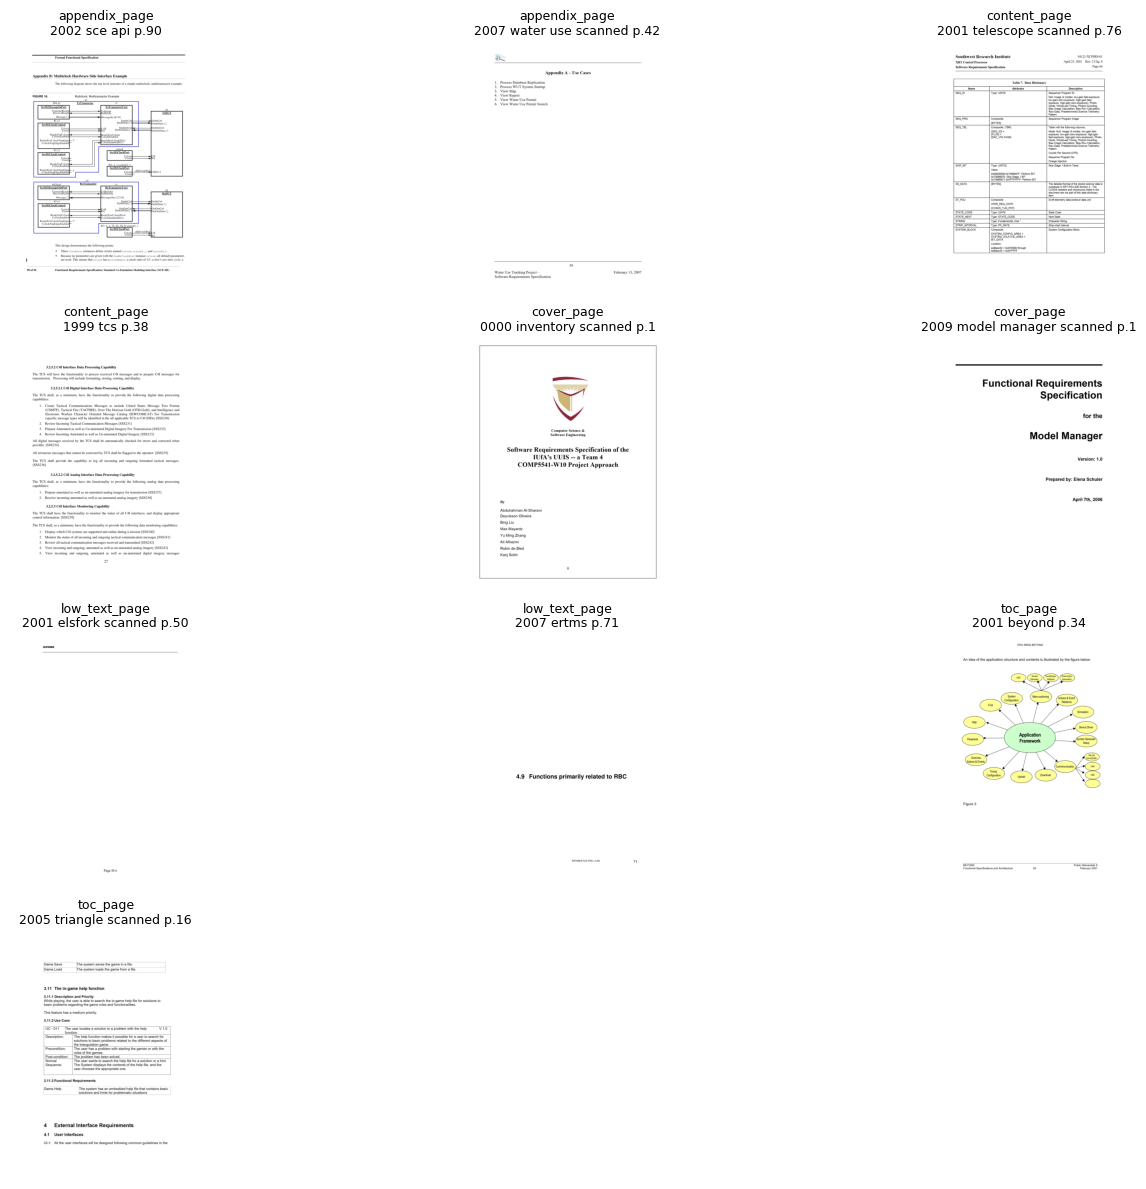

In [7]:
# =========================================================
# MODULE V1.4 — VISUAL CHECK
# =========================================================

import matplotlib.pyplot as plt
from PIL import Image

sample_df = (
    df_cv_dataset
    .groupby("page_type", group_keys=False)
    .apply(lambda x: x.sample(n=min(2, len(x)), random_state=42))
    .reset_index(drop=True)
)

plt.figure(figsize=(14, 12))

for i, row in enumerate(sample_df.head(12).itertuples(), start=1):
    img = Image.open(row.image_path).convert("RGB")

    plt.subplot(4, 3, i)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{row.page_type}\n{row.doc_id} p.{row.page_num}", fontsize=9)

plt.tight_layout()
plt.show()

In [8]:
# =========================================================
# MODULE V2 — DOCUMENT-LEVEL TRAIN / VALID / TEST SPLIT
# =========================================================

from sklearn.model_selection import GroupShuffleSplit
import pandas as pd

SEED = 42

df_cv_dataset = df_cv_dataset.copy()

groups = df_cv_dataset["doc_id"].astype(str)

# 85% train+val, 15% test
gss_test = GroupShuffleSplit(
    n_splits=1,
    test_size=0.15,
    random_state=SEED
)

train_val_idx, test_idx = next(
    gss_test.split(
        df_cv_dataset,
        df_cv_dataset["page_type_id"],
        groups
    )
)

df_train_val_cv = df_cv_dataset.iloc[train_val_idx].copy()
df_test_cv = df_cv_dataset.iloc[test_idx].copy()

# From remaining 85%, take 17.65% as validation => around 15% total
groups_train_val = df_train_val_cv["doc_id"].astype(str)

gss_val = GroupShuffleSplit(
    n_splits=1,
    test_size=0.1765,
    random_state=SEED
)

train_idx, val_idx = next(
    gss_val.split(
        df_train_val_cv,
        df_train_val_cv["page_type_id"],
        groups_train_val
    )
)

df_train_cv = df_train_val_cv.iloc[train_idx].copy()
df_val_cv = df_train_val_cv.iloc[val_idx].copy()

df_train_cv = df_train_cv.reset_index(drop=True)
df_val_cv = df_val_cv.reset_index(drop=True)
df_test_cv = df_test_cv.reset_index(drop=True)

df_train_cv["split"] = "train"
df_val_cv["split"] = "validation"
df_test_cv["split"] = "test"

df_cv_dataset_split = pd.concat(
    [df_train_cv, df_val_cv, df_test_cv],
    ignore_index=True
)

print("Train shape:", df_train_cv.shape)
print("Validation shape:", df_val_cv.shape)
print("Test shape:", df_test_cv.shape)

print("\nTrain distribution:")
print(df_train_cv["page_type"].value_counts())

print("\nValidation distribution:")
print(df_val_cv["page_type"].value_counts())

print("\nTest distribution:")
print(df_test_cv["page_type"].value_counts())

print("\nDocuments per split:")
display(
    df_cv_dataset_split
    .groupby("split")["doc_id"]
    .nunique()
    .reset_index(name="unique_documents")
)

print("\nPage type distribution by split:")
display(pd.crosstab(df_cv_dataset_split["split"], df_cv_dataset_split["page_type"]))

Train shape: (4255, 8)
Validation shape: (644, 8)
Test shape: (767, 8)

Train distribution:
page_type
content_page     3432
appendix_page     419
toc_page          203
low_text_page     152
cover_page         49
Name: count, dtype: int64

Validation distribution:
page_type
content_page     483
appendix_page     60
toc_page          53
low_text_page     35
cover_page        13
Name: count, dtype: int64

Test distribution:
page_type
content_page     649
appendix_page     80
toc_page          20
cover_page        13
low_text_page      5
Name: count, dtype: int64

Documents per split:


,split,unique_documents
0,test,19
1,train,86
2,validation,19



Page type distribution by split:


page_type,appendix_page,content_page,cover_page,low_text_page,toc_page
split,,,,,
test,80,649,13,5,20
train,419,3432,49,152,203
validation,60,483,13,35,53


In [9]:
# =========================================================
# MODULE V2.1 — TRANSFORMS / AUGMENTATION
# =========================================================

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

IMG_SIZE = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomRotation(degrees=5),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


class PageImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(row["image_path"]).convert("RGB")
        label = int(row["page_type_id"])

        if self.transform:
            image = self.transform(image)

        return {
            "pixel_values": image,
            "labels": torch.tensor(label, dtype=torch.long),
            "doc_id": row["doc_id"],
            "page_num": int(row["page_num"]),
            "image_path": row["image_path"],
            "page_type": row["page_type"]
        }


train_dataset_cv = PageImageDataset(df_train_cv, transform=train_transform)
val_dataset_cv = PageImageDataset(df_val_cv, transform=eval_transform)
test_dataset_cv = PageImageDataset(df_test_cv, transform=eval_transform)

train_loader_cv = DataLoader(
    train_dataset_cv,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader_cv = DataLoader(
    val_dataset_cv,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader_cv = DataLoader(
    test_dataset_cv,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print("Train batches:", len(train_loader_cv))
print("Validation batches:", len(val_loader_cv))
print("Test batches:", len(test_loader_cv))

batch = next(iter(train_loader_cv))
print("Batch image tensor:", batch["pixel_values"].shape)
print("Batch labels:", batch["labels"][:10])

Train batches: 133
Validation batches: 21
Test batches: 24


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Batch image tensor: torch.Size([32, 3, 224, 224])
Batch labels: tensor([1, 1, 3, 1, 1, 1, 0, 1, 4, 1])


In [10]:
# =========================================================
# MODULE V2.2 — SAVE CV SPLIT FILES
# =========================================================

cv_dataset_path = "/kaggle/working/v1_page_image_dataset.csv"
cv_train_path = "/kaggle/working/v2_cv_train_split.csv"
cv_val_path = "/kaggle/working/v2_cv_val_split.csv"
cv_test_path = "/kaggle/working/v2_cv_test_split.csv"

df_cv_dataset.to_csv(cv_dataset_path, index=False)
df_train_cv.to_csv(cv_train_path, index=False)
df_val_cv.to_csv(cv_val_path, index=False)
df_test_cv.to_csv(cv_test_path, index=False)

print("Saved:", cv_dataset_path)
print("Saved:", cv_train_path)
print("Saved:", cv_val_path)
print("Saved:", cv_test_path)

Saved: /kaggle/working/v1_page_image_dataset.csv
Saved: /kaggle/working/v2_cv_train_split.csv
Saved: /kaggle/working/v2_cv_val_split.csv
Saved: /kaggle/working/v2_cv_test_split.csv


# MODULE V3 — CUSTOM CNN FROM SCRATCH

In [11]:
# =========================================================
# MODULE V3.0 — DEVICE + CLASS WEIGHTS
# =========================================================

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

num_classes = len(label2id_page)

print("Number of classes:", num_classes)
print("Classes:", label2id_page)

# Compute class weights from train split
train_labels_np = df_train_cv["page_type_id"].values

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=train_labels_np
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

print("Class weights:")
for idx, weight in enumerate(class_weights.detach().cpu().numpy()):
    print(id2label_page[idx], ":", round(float(weight), 4))

Device: cpu
Number of classes: 5
Classes: {'appendix_page': 0, 'content_page': 1, 'cover_page': 2, 'low_text_page': 3, 'toc_page': 4}
Class weights:
appendix_page : 2.031
content_page : 0.248
cover_page : 17.3673
low_text_page : 5.5987
toc_page : 4.1921


In [12]:
# =========================================================
# MODULE V3.1 — CUSTOM CNN FROM SCRATCH
# =========================================================

class CustomSRSPageCNN(nn.Module):
    def __init__(self, num_classes):
        super(CustomSRSPageCNN, self).__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(p=0.5),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


cnn_model = CustomSRSPageCNN(num_classes=num_classes).to(device)

print(cnn_model)

total_params = sum(p.numel() for p in cnn_model.parameters())
trainable_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

CustomSRSPageCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=

In [13]:
# =========================================================
# MODULE V3.2 — LOSS, OPTIMIZER, SCHEDULER
# =========================================================

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(
    cnn_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

print("Loss: Weighted CrossEntropyLoss")
print("Optimizer: Adam")
print("Scheduler: ReduceLROnPlateau")

Loss: Weighted CrossEntropyLoss
Optimizer: Adam
Scheduler: ReduceLROnPlateau


In [14]:
# =========================================================
# MODULE V3.3 — TRAINING AND EVALUATION FUNCTIONS
# =========================================================

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from tqdm.auto import tqdm

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for batch in tqdm(dataloader, desc="Training", leave=False):
        images = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)

    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    epoch_weighted_f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)

    return {
        "loss": epoch_loss,
        "accuracy": epoch_acc,
        "macro_f1": epoch_macro_f1,
        "weighted_f1": epoch_weighted_f1
    }


def evaluate_model(model, dataloader, criterion, device, desc="Evaluation"):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc=desc, leave=False):
            images = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            running_loss += loss.item() * images.size(0)

            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())
            all_probs.extend(probs.detach().cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)

    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    epoch_weighted_f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)
    epoch_precision = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
    epoch_recall = recall_score(all_labels, all_preds, average="weighted", zero_division=0)

    return {
        "loss": epoch_loss,
        "accuracy": epoch_acc,
        "macro_f1": epoch_macro_f1,
        "weighted_f1": epoch_weighted_f1,
        "precision": epoch_precision,
        "recall": epoch_recall,
        "labels": np.array(all_labels),
        "preds": np.array(all_preds),
        "probs": np.array(all_probs)
    }

In [15]:
# =========================================================
# MODULE V3.4 — TRAIN CUSTOM CNN FROM SCRATCH
# =========================================================

import copy
from pathlib import Path

EPOCHS = 8

best_val_f1 = -1
best_model_state = None

history = []

cnn_model_path = "/kaggle/working/v3_custom_cnn_page_classifier.pt"

for epoch in range(1, EPOCHS + 1):
    print("=" * 80)
    print(f"Epoch {epoch}/{EPOCHS}")
    print("=" * 80)

    train_metrics = train_one_epoch(
        cnn_model,
        train_loader_cv,
        criterion,
        optimizer,
        device
    )

    val_metrics = evaluate_model(
        cnn_model,
        val_loader_cv,
        criterion,
        device,
        desc="Validation"
    )

    scheduler.step(val_metrics["loss"])

    row = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "train_weighted_f1": train_metrics["weighted_f1"],
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_macro_f1": val_metrics["macro_f1"],
        "val_weighted_f1": val_metrics["weighted_f1"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"]
    }

    history.append(row)

    print("Train loss:", round(train_metrics["loss"], 4))
    print("Train accuracy:", round(train_metrics["accuracy"], 4))
    print("Train macro F1:", round(train_metrics["macro_f1"], 4))
    print("Train weighted F1:", round(train_metrics["weighted_f1"], 4))

    print("\nValidation loss:", round(val_metrics["loss"], 4))
    print("Validation accuracy:", round(val_metrics["accuracy"], 4))
    print("Validation macro F1:", round(val_metrics["macro_f1"], 4))
    print("Validation weighted F1:", round(val_metrics["weighted_f1"], 4))

    if val_metrics["macro_f1"] > best_val_f1:
        best_val_f1 = val_metrics["macro_f1"]
        best_model_state = copy.deepcopy(cnn_model.state_dict())
        torch.save(best_model_state, cnn_model_path)
        print("\nNew best model saved:", cnn_model_path)

df_cnn_history = pd.DataFrame(history)

history_path = "/kaggle/working/v3_custom_cnn_training_history.csv"
df_cnn_history.to_csv(history_path, index=False)

print("\nTraining finished.")
print("Best validation macro F1:", round(best_val_f1, 4))
print("Saved history:", history_path)
print("Saved model:", cnn_model_path)

display(df_cnn_history)

Epoch 1/8


Training:   0%|          | 0/133 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Validation:   0%|          | 0/21 [00:00<?, ?it/s]

Train loss: 1.2535
Train accuracy: 0.3427
Train macro F1: 0.2517
Train weighted F1: 0.4182

Validation loss: 1.2464
Validation accuracy: 0.3975
Validation macro F1: 0.2199
Validation weighted F1: 0.443

New best model saved: /kaggle/working/v3_custom_cnn_page_classifier.pt
Epoch 2/8


...

Training:   0%|          | 0/133 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e6347d7ade0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-

Validation:   0%|          | 0/21 [00:00<?, ?it/s]

Train loss: 0.9326
Train accuracy: 0.4912
Train macro F1: 0.3728
Train weighted F1: 0.5608

Validation loss: 0.7997
Validation accuracy: 0.5683
Validation macro F1: 0.4501
Validation weighted F1: 0.5992

Training finished.
Best validation macro F1: 0.5096
Saved history: /kaggle/working/v3_custom_cnn_training_history.csv
Saved model: /kaggle/working/v3_custom_cnn_page_classifier.pt


,epoch,train_loss,train_accuracy,train_macro_f1,train_weighted_f1,val_loss,val_accuracy,val_macro_f1,val_weighted_f1,val_precision,val_recall
0,1,1.253464,0.342656,0.251658,0.418219,1.246445,0.397516,0.219865,0.442979,0.588547,0.397516
1,2,1.045824,0.380964,0.299252,0.456170,5.197289,0.093168,0.065118,0.028882,0.017246,0.093168
2,3,1.022200,0.399295,0.309272,0.477035,0.890856,0.369565,0.375709,0.412708,0.684166,0.369565
3,4,0.970938,0.370623,0.321286,0.440901,0.846573,0.462733,0.437412,0.507310,0.697202,0.462733
4,5,0.978423,0.415981,0.343820,0.494032,1.055668,0.478261,0.415159,0.526266,0.682221,0.478261
5,6,0.929347,0.449824,0.367330,0.522364,0.824238,0.377329,0.434006,0.422052,0.693962,0.377329
6,7,0.945283,0.472385,0.372356,0.543024,0.844271,0.537267,0.509564,0.594184,0.729705,0.537267
7,8,0.932571,0.491187,0.372786,0.560751,0.799716,0.568323,0.450142,0.599210,0.726501,0.568323


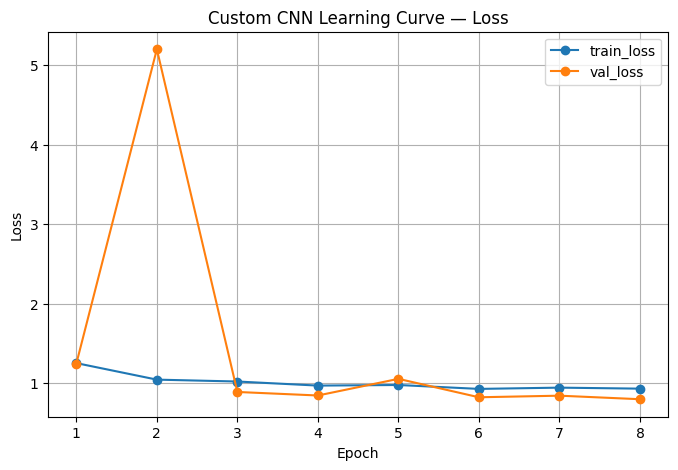

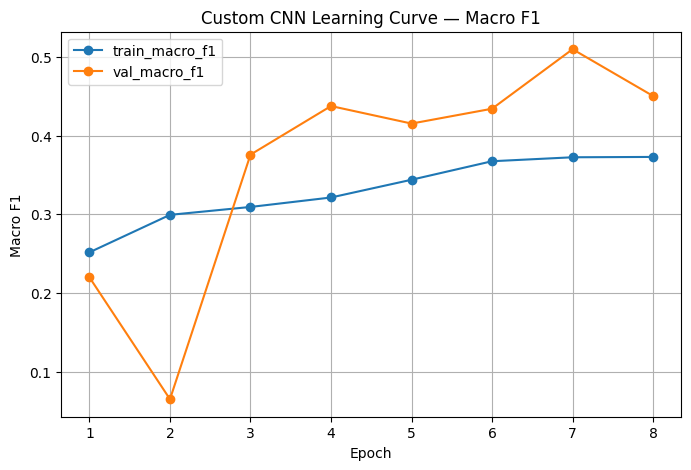

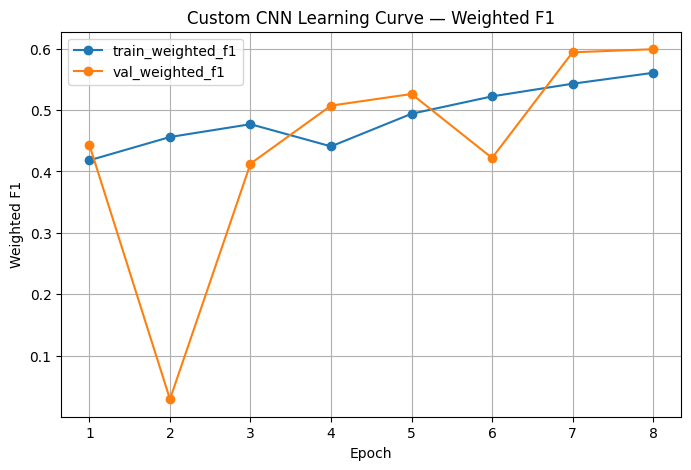

In [16]:
# =========================================================
# MODULE V3.5 — LEARNING CURVES
# =========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(df_cnn_history["epoch"], df_cnn_history["train_loss"], marker="o", label="train_loss")
plt.plot(df_cnn_history["epoch"], df_cnn_history["val_loss"], marker="o", label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Custom CNN Learning Curve — Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(df_cnn_history["epoch"], df_cnn_history["train_macro_f1"], marker="o", label="train_macro_f1")
plt.plot(df_cnn_history["epoch"], df_cnn_history["val_macro_f1"], marker="o", label="val_macro_f1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("Custom CNN Learning Curve — Macro F1")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(df_cnn_history["epoch"], df_cnn_history["train_weighted_f1"], marker="o", label="train_weighted_f1")
plt.plot(df_cnn_history["epoch"], df_cnn_history["val_weighted_f1"], marker="o", label="val_weighted_f1")
plt.xlabel("Epoch")
plt.ylabel("Weighted F1")
plt.title("Custom CNN Learning Curve — Weighted F1")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
# =========================================================
# MODULE V3.6 — TEST EVALUATION
# =========================================================

from sklearn.metrics import classification_report, confusion_matrix

# Load best model
cnn_model.load_state_dict(torch.load(cnn_model_path, map_location=device))
cnn_model.to(device)

test_metrics = evaluate_model(
    cnn_model,
    test_loader_cv,
    criterion,
    device,
    desc="Test"
)

print("=" * 80)
print("CUSTOM CNN TEST RESULTS")
print("=" * 80)

print("Test loss:", round(test_metrics["loss"], 4))
print("Test accuracy:", round(test_metrics["accuracy"], 4))
print("Test macro F1:", round(test_metrics["macro_f1"], 4))
print("Test weighted F1:", round(test_metrics["weighted_f1"], 4))
print("Test precision:", round(test_metrics["precision"], 4))
print("Test recall:", round(test_metrics["recall"], 4))

target_names = [id2label_page[i] for i in range(num_classes)]

print("\nClassification report:")
print(classification_report(
    test_metrics["labels"],
    test_metrics["preds"],
    target_names=target_names,
    zero_division=0
))

Test:   0%|          | 0/24 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


CUSTOM CNN TEST RESULTS
Test loss: 1.0852
Test accuracy: 0.6832
Test macro F1: 0.4805
Test weighted F1: 0.725
Test precision: 0.7936
Test recall: 0.6832

Classification report:
               precision    recall  f1-score   support

appendix_page       0.17      0.34      0.23        80
 content_page       0.89      0.72      0.80       649
   cover_page       0.62      0.77      0.69        13
low_text_page       0.16      0.80      0.27         5
     toc_page       0.31      0.65      0.42        20

     accuracy                           0.68       767
    macro avg       0.43      0.66      0.48       767
 weighted avg       0.79      0.68      0.72       767



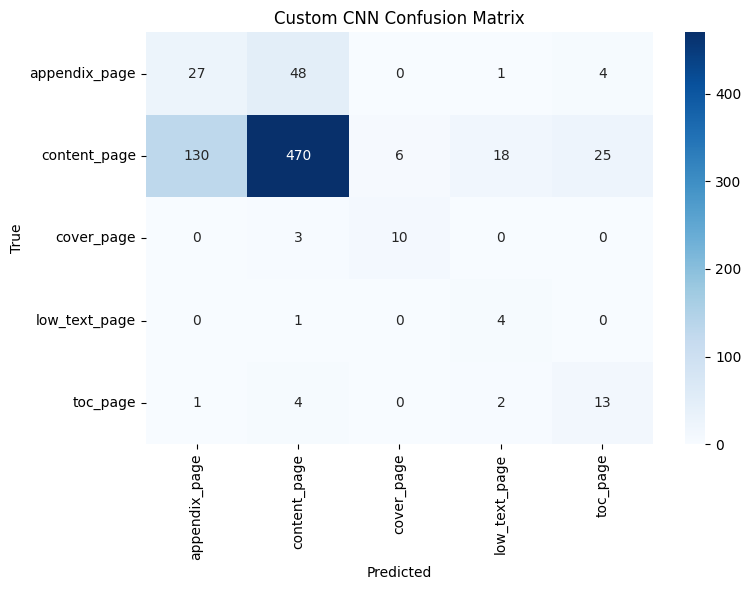

In [18]:
# =========================================================
# MODULE V3.7 — CONFUSION MATRIX
# =========================================================

import seaborn as sns

cm = confusion_matrix(
    test_metrics["labels"],
    test_metrics["preds"],
    labels=list(range(num_classes))
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=target_names,
    yticklabels=target_names,
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Custom CNN Confusion Matrix")
plt.tight_layout()
plt.show()

In [19]:
# =========================================================
# MODULE V3.8 — SAVE CUSTOM CNN TEST PREDICTIONS
# =========================================================

df_test_predictions = df_test_cv.copy().reset_index(drop=True)

test_probs = test_metrics["probs"]
test_preds = test_metrics["preds"]

df_test_predictions["cnn_pred_id"] = test_preds
df_test_predictions["cnn_prediction"] = [
    id2label_page[int(i)] for i in test_preds
]

df_test_predictions["cnn_confidence"] = test_probs.max(axis=1)

for idx in range(num_classes):
    class_name = id2label_page[idx]
    df_test_predictions[f"cnn_prob_{class_name}"] = test_probs[:, idx]

cnn_test_pred_path = "/kaggle/working/v3_custom_cnn_test_predictions.csv"
df_test_predictions.to_csv(cnn_test_pred_path, index=False)

print("Saved:", cnn_test_pred_path)

display(df_test_predictions[
    [
        "doc_id",
        "page_num",
        "page_type",
        "cnn_prediction",
        "cnn_confidence",
        "image_path"
    ]
].head(30))

Saved: /kaggle/working/v3_custom_cnn_test_predictions.csv


,doc_id,page_num,page_type,cnn_prediction,cnn_confidence,image_path
0,0000 inventory,1,cover_page,cover_page,0.453678,/kaggle/input/datasets/cyrinemejrii/page-image...
1,0000 inventory,2,toc_page,toc_page,0.387853,/kaggle/input/datasets/cyrinemejrii/page-image...
2,0000 inventory,3,content_page,content_page,0.401712,/kaggle/input/datasets/cyrinemejrii/page-image...
3,0000 inventory,4,content_page,content_page,0.367883,/kaggle/input/datasets/cyrinemejrii/page-image...
4,0000 inventory,5,content_page,content_page,0.387219,/kaggle/input/datasets/cyrinemejrii/page-image...
5,0000 inventory,6,content_page,content_page,0.374813,/kaggle/input/datasets/cyrinemejrii/page-image...
6,0000 inventory,7,content_page,appendix_page,0.379746,/kaggle/input/datasets/cyrinemejrii/page-image...
7,0000 inventory,8,content_page,content_page,0.373023,/kaggle/input/datasets/cyrinemejrii/page-image...
8,0000 inventory,9,content_page,content_page,0.386194,/kaggle/input/datasets/cyrinemejrii/page-image...
9,0000 inventory,10,content_page,content_page,0.379991,/kaggle/input/datasets/cyrinemejrii/page-image...


# MODULE V4 — PRETRAINED RESNET18 PAGE CLASSIFIER

In this module, we train a pretrained ResNet18 model for SRS page image classification.

The goal is to compare a custom CNN trained from scratch with a pretrained model initialized from ImageNet weights.

ResNet18 is selected because it is lightweight, stable on Kaggle, fast to fine-tune, and compatible with Grad-CAM explainability.

In [20]:
# =========================================================
# MODULE V4.0 — SAFE DATALOADERS FOR PRETRAINED RESNET18
# =========================================================

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
import random

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

IMG_SIZE = 224
BATCH_SIZE = 32

# ImageNet normalization for pretrained ResNet18
resnet_train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(degrees=5),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

resnet_eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


class SRSPageResNetDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image_path = row["image_path"]
        label = int(row["page_type_id"])

        image = Image.open(image_path)

        # Fix palette transparency warnings
        if image.mode in ["P", "LA"]:
            image = image.convert("RGBA")

        image = image.convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return {
            "pixel_values": image,
            "labels": torch.tensor(label, dtype=torch.long),
            "doc_id": row["doc_id"],
            "page_num": int(row["page_num"]),
            "image_path": row["image_path"],
            "page_type": row["page_type"]
        }


resnet_train_dataset = SRSPageResNetDataset(df_train_cv, transform=resnet_train_transform)
resnet_val_dataset = SRSPageResNetDataset(df_val_cv, transform=resnet_eval_transform)
resnet_test_dataset = SRSPageResNetDataset(df_test_cv, transform=resnet_eval_transform)

resnet_train_loader = DataLoader(
    resnet_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

resnet_val_loader = DataLoader(
    resnet_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

resnet_test_loader = DataLoader(
    resnet_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Train dataset:", len(resnet_train_dataset))
print("Validation dataset:", len(resnet_val_dataset))
print("Test dataset:", len(resnet_test_dataset))

batch = next(iter(resnet_train_loader))

print("Batch image tensor:", batch["pixel_values"].shape)
print("Batch labels:", batch["labels"][:10])

Device: cpu
Train dataset: 4255
Validation dataset: 644
Test dataset: 767
Batch image tensor: torch.Size([32, 3, 224, 224])
Batch labels: tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])


In [21]:
# =========================================================
# MODULE V4.1 — LOAD PRETRAINED RESNET18
# =========================================================

import torch.nn as nn
import torchvision.models as models

num_classes = len(label2id_page)

print("Number of classes:", num_classes)
print("Classes:", label2id_page)

try:
    from torchvision.models import ResNet18_Weights

    weights = ResNet18_Weights.IMAGENET1K_V1
    resnet_model = models.resnet18(weights=weights)
    print("Loaded ResNet18 with ImageNet pretrained weights.")

except Exception as e:
    print("Could not load pretrained weights automatically.")
    print("Error:", e)
    print("Loading ResNet18 without pretrained weights. If Kaggle internet is disabled, enable it or use cached weights.")
    resnet_model = models.resnet18(weights=None)

# Replace final classification layer
in_features = resnet_model.fc.in_features

resnet_model.fc = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(in_features, num_classes)
)

resnet_model = resnet_model.to(device)

print(resnet_model)

total_params = sum(p.numel() for p in resnet_model.parameters())
trainable_params = sum(p.numel() for p in resnet_model.parameters() if p.requires_grad)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Number of classes: 5
Classes: {'appendix_page': 0, 'content_page': 1, 'cover_page': 2, 'low_text_page': 3, 'toc_page': 4}
Loaded ResNet18 with ImageNet pretrained weights.
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3),

In [22]:
# =========================================================
# MODULE V4.2 — FREEZE BACKBONE FOR PHASE 1
# =========================================================

for param in resnet_model.parameters():
    param.requires_grad = False

# Unfreeze classification head only
for param in resnet_model.fc.parameters():
    param.requires_grad = True

trainable_params = sum(p.numel() for p in resnet_model.parameters() if p.requires_grad)

print("Trainable parameters after freezing backbone:", trainable_params)

Trainable parameters after freezing backbone: 2565


In [23]:
# =========================================================
# MODULE V4.3 — LOSS, OPTIMIZER, SCHEDULER
# =========================================================

import torch.optim as optim
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

train_labels_np = df_train_cv["page_type_id"].values

resnet_class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=train_labels_np
)

resnet_class_weights = torch.tensor(
    resnet_class_weights,
    dtype=torch.float
).to(device)

print("Class weights:")
for idx, weight in enumerate(resnet_class_weights.detach().cpu().numpy()):
    print(id2label_page[idx], ":", round(float(weight), 4))

resnet_criterion = nn.CrossEntropyLoss(weight=resnet_class_weights)

resnet_optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, resnet_model.parameters()),
    lr=1e-3,
    weight_decay=1e-4
)

resnet_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    resnet_optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

print("Loss: Weighted CrossEntropyLoss")
print("Optimizer: AdamW")
print("Scheduler: ReduceLROnPlateau")

Class weights:
appendix_page : 2.031
content_page : 0.248
cover_page : 17.3673
low_text_page : 5.5987
toc_page : 4.1921
Loss: Weighted CrossEntropyLoss
Optimizer: AdamW
Scheduler: ReduceLROnPlateau


In [24]:
# =========================================================
# MODULE V4.4 — TRAINING AND EVALUATION FUNCTIONS
# =========================================================

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from tqdm.auto import tqdm

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for batch in tqdm(dataloader, desc="Training", leave=False):
        images = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)

    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    epoch_weighted_f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)

    return {
        "loss": epoch_loss,
        "accuracy": epoch_acc,
        "macro_f1": epoch_macro_f1,
        "weighted_f1": epoch_weighted_f1
    }


def evaluate_model(model, dataloader, criterion, device, desc="Evaluation"):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc=desc, leave=False):
            images = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            running_loss += loss.item() * images.size(0)

            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())
            all_probs.extend(probs.detach().cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)

    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    epoch_weighted_f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)
    epoch_precision = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
    epoch_recall = recall_score(all_labels, all_preds, average="weighted", zero_division=0)

    return {
        "loss": epoch_loss,
        "accuracy": epoch_acc,
        "macro_f1": epoch_macro_f1,
        "weighted_f1": epoch_weighted_f1,
        "precision": epoch_precision,
        "recall": epoch_recall,
        "labels": np.array(all_labels),
        "preds": np.array(all_preds),
        "probs": np.array(all_probs)
    }

In [25]:
# =========================================================
# MODULE V4.5 — TRAIN RESNET18 PHASE 1: CLASSIFICATION HEAD
# =========================================================

import copy
import pandas as pd
from pathlib import Path

PHASE1_EPOCHS = 5

best_val_f1 = -1
best_resnet_state = None

resnet_history = []

resnet_model_path = "/kaggle/working/v4_resnet18_page_classifier.pt"

for epoch in range(1, PHASE1_EPOCHS + 1):
    print("=" * 80)
    print(f"ResNet18 Phase 1 — Epoch {epoch}/{PHASE1_EPOCHS}")
    print("=" * 80)

    train_metrics = train_one_epoch(
        resnet_model,
        resnet_train_loader,
        resnet_criterion,
        resnet_optimizer,
        device
    )

    val_metrics = evaluate_model(
        resnet_model,
        resnet_val_loader,
        resnet_criterion,
        device,
        desc="Validation"
    )

    resnet_scheduler.step(val_metrics["loss"])

    row = {
        "phase": "head_only",
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "train_weighted_f1": train_metrics["weighted_f1"],
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_macro_f1": val_metrics["macro_f1"],
        "val_weighted_f1": val_metrics["weighted_f1"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"]
    }

    resnet_history.append(row)

    print("Train loss:", round(train_metrics["loss"], 4))
    print("Train accuracy:", round(train_metrics["accuracy"], 4))
    print("Train macro F1:", round(train_metrics["macro_f1"], 4))
    print("Train weighted F1:", round(train_metrics["weighted_f1"], 4))

    print("\nValidation loss:", round(val_metrics["loss"], 4))
    print("Validation accuracy:", round(val_metrics["accuracy"], 4))
    print("Validation macro F1:", round(val_metrics["macro_f1"], 4))
    print("Validation weighted F1:", round(val_metrics["weighted_f1"], 4))

    if val_metrics["macro_f1"] > best_val_f1:
        best_val_f1 = val_metrics["macro_f1"]
        best_resnet_state = copy.deepcopy(resnet_model.state_dict())
        torch.save(best_resnet_state, resnet_model_path)
        print("\nNew best ResNet18 model saved:", resnet_model_path)

print("\nPhase 1 finished.")
print("Best validation macro F1:", round(best_val_f1, 4))

ResNet18 Phase 1 — Epoch 1/5


Training:   0%|          | 0/133 [00:00<?, ?it/s]

Validation:   0%|          | 0/21 [00:00<?, ?it/s]

Train loss: 1.4044
Train accuracy: 0.3546
Train macro F1: 0.2386
Train weighted F1: 0.4376

Validation loss: 1.1665
Validation accuracy: 0.6708
Validation macro F1: 0.4525
Validation weighted F1: 0.6627

New best ResNet18 model saved: /kaggle/working/v4_resnet18_page_classifier.pt
ResNet18 Phase 1 — Epoch 2/5


Training:   0%|          | 0/133 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/21 [00:00<?, ?it/s]

Train loss: 0.9594
Train accuracy: 0.4778
Train macro F1: 0.3698
Train weighted F1: 0.5467

Validation loss: 0.9028
Validation accuracy: 0.3882
Validation macro F1: 0.3916
Validation weighted F1: 0.4307
ResNet18 Phase 1 — Epoch 5/5


Training:   0%|          | 0/133 [00:00<?, ?it/s]

Validation:   0%|          | 0/21 [00:00<?, ?it/s]

Train loss: 0.9528
Train accuracy: 0.4931
Train macro F1: 0.3808
Train weighted F1: 0.5615

Validation loss: 1.0716
Validation accuracy: 0.427
Validation macro F1: 0.4639
Validation weighted F1: 0.4882

New best ResNet18 model saved: /kaggle/working/v4_resnet18_page_classifier.pt

Phase 1 finished.
Best validation macro F1: 0.4639


In [26]:
# =========================================================
# MODULE V4.6 — UNFREEZE LAYER4 FOR PHASE 2 FINE-TUNING
# =========================================================

# Load best phase 1 model
resnet_model.load_state_dict(torch.load(resnet_model_path, map_location=device))
resnet_model.to(device)

# Freeze all
for param in resnet_model.parameters():
    param.requires_grad = False

# Unfreeze layer4 and fc
for param in resnet_model.layer4.parameters():
    param.requires_grad = True

for param in resnet_model.fc.parameters():
    param.requires_grad = True

trainable_params = sum(p.numel() for p in resnet_model.parameters() if p.requires_grad)

print("Trainable parameters after unfreezing layer4 + fc:", trainable_params)

resnet_optimizer = optim.AdamW(
    [
        {"params": resnet_model.layer4.parameters(), "lr": 1e-4},
        {"params": resnet_model.fc.parameters(), "lr": 1e-3}
    ],
    weight_decay=1e-4
)

resnet_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    resnet_optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

print("Fine-tuning optimizer ready.")

Trainable parameters after unfreezing layer4 + fc: 8396293
Fine-tuning optimizer ready.


In [27]:
# =========================================================
# MODULE V4.7 — TRAIN RESNET18 PHASE 2: FINE-TUNE LAYER4
# =========================================================

PHASE2_EPOCHS = 7

for epoch in range(1, PHASE2_EPOCHS + 1):
    print("=" * 80)
    print(f"ResNet18 Phase 2 — Epoch {epoch}/{PHASE2_EPOCHS}")
    print("=" * 80)

    train_metrics = train_one_epoch(
        resnet_model,
        resnet_train_loader,
        resnet_criterion,
        resnet_optimizer,
        device
    )

    val_metrics = evaluate_model(
        resnet_model,
        resnet_val_loader,
        resnet_criterion,
        device,
        desc="Validation"
    )

    resnet_scheduler.step(val_metrics["loss"])

    row = {
        "phase": "fine_tune_layer4",
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "train_weighted_f1": train_metrics["weighted_f1"],
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_macro_f1": val_metrics["macro_f1"],
        "val_weighted_f1": val_metrics["weighted_f1"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"]
    }

    resnet_history.append(row)

    print("Train loss:", round(train_metrics["loss"], 4))
    print("Train accuracy:", round(train_metrics["accuracy"], 4))
    print("Train macro F1:", round(train_metrics["macro_f1"], 4))
    print("Train weighted F1:", round(train_metrics["weighted_f1"], 4))

    print("\nValidation loss:", round(val_metrics["loss"], 4))
    print("Validation accuracy:", round(val_metrics["accuracy"], 4))
    print("Validation macro F1:", round(val_metrics["macro_f1"], 4))
    print("Validation weighted F1:", round(val_metrics["weighted_f1"], 4))

    if val_metrics["macro_f1"] > best_val_f1:
        best_val_f1 = val_metrics["macro_f1"]
        best_resnet_state = copy.deepcopy(resnet_model.state_dict())
        torch.save(best_resnet_state, resnet_model_path)
        print("\nNew best ResNet18 model saved:", resnet_model_path)

df_resnet_history = pd.DataFrame(resnet_history)

resnet_history_path = "/kaggle/working/v4_resnet18_training_history.csv"
df_resnet_history.to_csv(resnet_history_path, index=False)

print("\nResNet18 training finished.")
print("Best validation macro F1:", round(best_val_f1, 4))
print("Saved history:", resnet_history_path)
print("Saved model:", resnet_model_path)

display(df_resnet_history)

ResNet18 Phase 2 — Epoch 1/7


Training:   0%|          | 0/133 [00:00<?, ?it/s]

Validation:   0%|          | 0/21 [00:00<?, ?it/s]

Train loss: 0.8879
Train accuracy: 0.5262
Train macro F1: 0.4268
Train weighted F1: 0.5916

Validation loss: 0.7133
Validation accuracy: 0.4519
Validation macro F1: 0.4486
Validation weighted F1: 0.5057
ResNet18 Phase 2 — Epoch 2/7


Training:   0%|          | 0/133 [00:00<?, ?it/s]

...

Train loss: 0.3403
Train accuracy: 0.7871
Train macro F1: 0.7132
Train weighted F1: 0.8108

Validation loss: 0.7053
Validation accuracy: 0.6289
Validation macro F1: 0.6544
Validation weighted F1: 0.6752
ResNet18 Phase 2 — Epoch 7/7


Training:   0%|          | 0/133 [00:00<?, ?it/s]

Validation:   0%|          | 0/21 [00:00<?, ?it/s]

Train loss: 0.2834
Train accuracy: 0.8209
Train macro F1: 0.748
Train weighted F1: 0.839

Validation loss: 0.5398
Validation accuracy: 0.7686
Validation macro F1: 0.7169
Validation weighted F1: 0.7893

New best ResNet18 model saved: /kaggle/working/v4_resnet18_page_classifier.pt

ResNet18 training finished.
Best validation macro F1: 0.7169
Saved history: /kaggle/working/v4_resnet18_training_history.csv
Saved model: /kaggle/working/v4_resnet18_page_classifier.pt


,phase,epoch,train_loss,train_accuracy,train_macro_f1,train_weighted_f1,val_loss,val_accuracy,val_macro_f1,val_weighted_f1,val_precision,val_recall
0,head_only,1,1.404441,0.354642,0.238609,0.437600,1.166479,0.670807,0.452487,0.662749,0.660998,0.670807
1,head_only,2,1.094042,0.434078,0.329377,0.508678,1.223364,0.673913,0.445969,0.661998,0.679454,0.673913
2,head_only,3,1.012952,0.461340,0.360455,0.532382,0.971987,0.422360,0.365386,0.471117,0.649850,0.422360
3,head_only,4,0.959377,0.477791,0.369773,0.546679,0.902769,0.388199,0.391636,0.430686,0.681618,0.388199
4,head_only,5,0.952786,0.493067,0.380824,0.561490,1.071590,0.427019,0.463915,0.488222,0.702443,0.427019
5,fine_tune_layer4,1,0.887885,0.526204,0.426797,0.591587,0.713280,0.451863,0.448560,0.505726,0.735713,0.451863
6,fine_tune_layer4,2,0.726690,0.602115,0.540103,0.657935,0.713439,0.461180,0.512965,0.512650,0.807212,0.461180
7,fine_tune_layer4,3,0.512049,0.674501,0.603554,0.717467,0.565398,0.565217,0.628622,0.618628,0.822144,0.565217
8,fine_tune_layer4,4,0.489807,0.725264,0.658120,0.760861,0.619594,0.583851,0.626273,0.632594,0.812771,0.583851
9,fine_tune_layer4,5,0.396983,0.754172,0.680531,0.784549,0.578348,0.680124,0.679839,0.719260,0.815627,0.680124


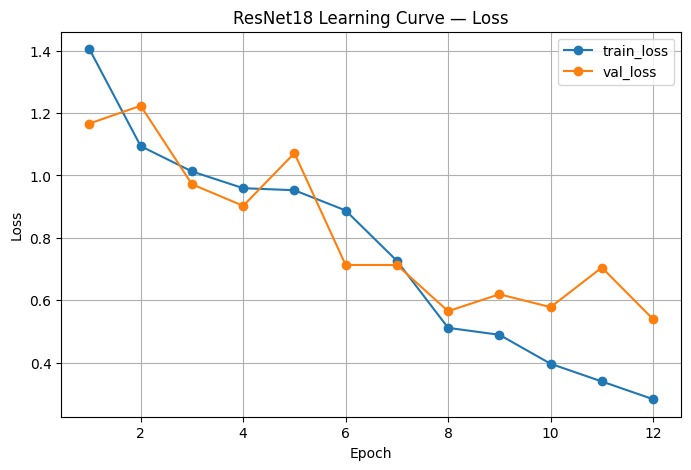

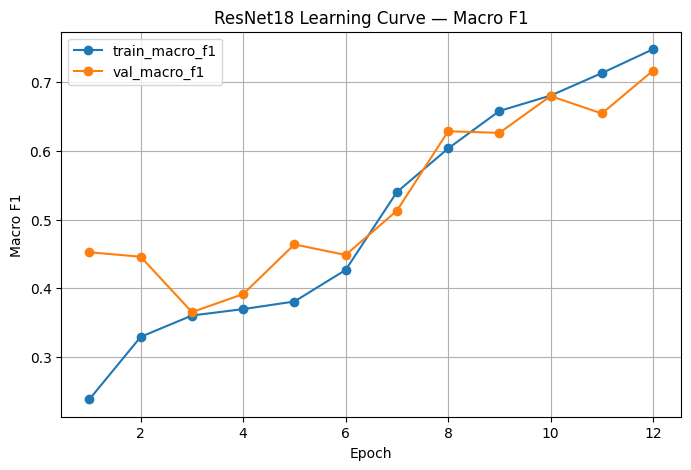

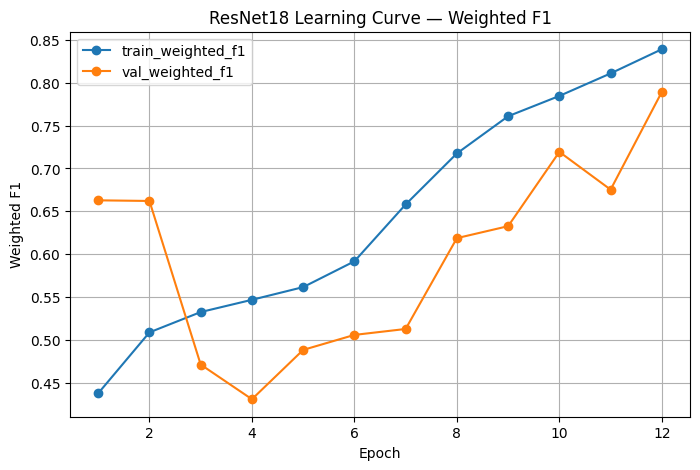

In [28]:
# =========================================================
# MODULE V4.8 — RESNET18 LEARNING CURVES
# =========================================================

import matplotlib.pyplot as plt

df_resnet_history_plot = df_resnet_history.copy()
df_resnet_history_plot["global_epoch"] = range(1, len(df_resnet_history_plot) + 1)

plt.figure(figsize=(8, 5))
plt.plot(df_resnet_history_plot["global_epoch"], df_resnet_history_plot["train_loss"], marker="o", label="train_loss")
plt.plot(df_resnet_history_plot["global_epoch"], df_resnet_history_plot["val_loss"], marker="o", label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet18 Learning Curve — Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(df_resnet_history_plot["global_epoch"], df_resnet_history_plot["train_macro_f1"], marker="o", label="train_macro_f1")
plt.plot(df_resnet_history_plot["global_epoch"], df_resnet_history_plot["val_macro_f1"], marker="o", label="val_macro_f1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("ResNet18 Learning Curve — Macro F1")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(df_resnet_history_plot["global_epoch"], df_resnet_history_plot["train_weighted_f1"], marker="o", label="train_weighted_f1")
plt.plot(df_resnet_history_plot["global_epoch"], df_resnet_history_plot["val_weighted_f1"], marker="o", label="val_weighted_f1")
plt.xlabel("Epoch")
plt.ylabel("Weighted F1")
plt.title("ResNet18 Learning Curve — Weighted F1")
plt.legend()
plt.grid(True)
plt.show()

In [29]:
# =========================================================
# MODULE V4.9 — RESNET18 TEST EVALUATION
# =========================================================

from sklearn.metrics import classification_report, confusion_matrix

resnet_model.load_state_dict(torch.load(resnet_model_path, map_location=device))
resnet_model.to(device)

resnet_test_metrics = evaluate_model(
    resnet_model,
    resnet_test_loader,
    resnet_criterion,
    device,
    desc="ResNet18 Test"
)

print("=" * 80)
print("RESNET18 TEST RESULTS")
print("=" * 80)

print("Test loss:", round(resnet_test_metrics["loss"], 4))
print("Test accuracy:", round(resnet_test_metrics["accuracy"], 4))
print("Test macro F1:", round(resnet_test_metrics["macro_f1"], 4))
print("Test weighted F1:", round(resnet_test_metrics["weighted_f1"], 4))
print("Test precision:", round(resnet_test_metrics["precision"], 4))
print("Test recall:", round(resnet_test_metrics["recall"], 4))

target_names = [id2label_page[i] for i in range(num_classes)]

print("\nClassification report:")
print(classification_report(
    resnet_test_metrics["labels"],
    resnet_test_metrics["preds"],
    target_names=target_names,
    zero_division=0
))

ResNet18 Test:   0%|          | 0/24 [00:00<?, ?it/s]

RESNET18 TEST RESULTS
Test loss: 1.0264
Test accuracy: 0.8162
Test macro F1: 0.5711
Test weighted F1: 0.8314
Test precision: 0.855
Test recall: 0.8162

Classification report:
               precision    recall  f1-score   support

appendix_page       0.39      0.56      0.46        80
 content_page       0.93      0.86      0.90       649
   cover_page       0.67      0.62      0.64        13
low_text_page       0.27      0.80      0.40         5
     toc_page       0.39      0.55      0.46        20

     accuracy                           0.82       767
    macro avg       0.53      0.68      0.57       767
 weighted avg       0.85      0.82      0.83       767



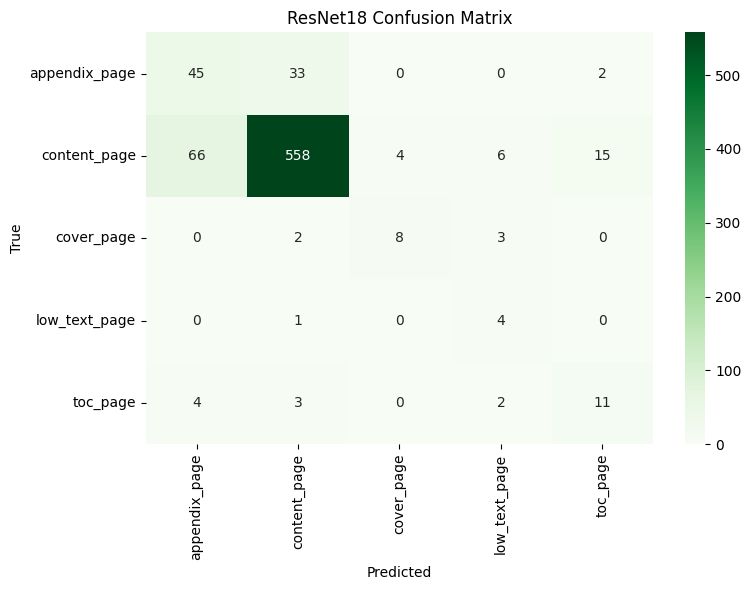

In [30]:
# =========================================================
# MODULE V4.10 — RESNET18 CONFUSION MATRIX
# =========================================================

import seaborn as sns
import matplotlib.pyplot as plt

resnet_cm = confusion_matrix(
    resnet_test_metrics["labels"],
    resnet_test_metrics["preds"],
    labels=list(range(num_classes))
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    resnet_cm,
    annot=True,
    fmt="d",
    xticklabels=target_names,
    yticklabels=target_names,
    cmap="Greens"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("ResNet18 Confusion Matrix")
plt.tight_layout()
plt.show()

In [31]:
# =========================================================
# MODULE V4.11 — SAVE RESNET18 TEST PREDICTIONS
# =========================================================

df_resnet_test_predictions = df_test_cv.copy().reset_index(drop=True)

resnet_test_probs = resnet_test_metrics["probs"]
resnet_test_preds = resnet_test_metrics["preds"]

df_resnet_test_predictions["resnet18_pred_id"] = resnet_test_preds
df_resnet_test_predictions["resnet18_prediction"] = [
    id2label_page[int(i)] for i in resnet_test_preds
]

df_resnet_test_predictions["resnet18_confidence"] = resnet_test_probs.max(axis=1)

for idx in range(num_classes):
    class_name = id2label_page[idx]
    df_resnet_test_predictions[f"resnet18_prob_{class_name}"] = resnet_test_probs[:, idx]

resnet_test_pred_path = "/kaggle/working/v4_resnet18_test_predictions.csv"

df_resnet_test_predictions.to_csv(resnet_test_pred_path, index=False)

print("Saved:", resnet_test_pred_path)

display(df_resnet_test_predictions[
    [
        "doc_id",
        "page_num",
        "page_type",
        "resnet18_prediction",
        "resnet18_confidence",
        "image_path"
    ]
].head(30))

Saved: /kaggle/working/v4_resnet18_test_predictions.csv


,doc_id,page_num,page_type,resnet18_prediction,resnet18_confidence,image_path
0,0000 inventory,1,cover_page,cover_page,0.953463,/kaggle/input/datasets/cyrinemejrii/page-image...
1,0000 inventory,2,toc_page,toc_page,0.840669,/kaggle/input/datasets/cyrinemejrii/page-image...
2,0000 inventory,3,content_page,content_page,0.598074,/kaggle/input/datasets/cyrinemejrii/page-image...
3,0000 inventory,4,content_page,content_page,0.999739,/kaggle/input/datasets/cyrinemejrii/page-image...
4,0000 inventory,5,content_page,content_page,0.984417,/kaggle/input/datasets/cyrinemejrii/page-image...
5,0000 inventory,6,content_page,content_page,0.996006,/kaggle/input/datasets/cyrinemejrii/page-image...
6,0000 inventory,7,content_page,content_page,0.616504,/kaggle/input/datasets/cyrinemejrii/page-image...
7,0000 inventory,8,content_page,toc_page,0.722812,/kaggle/input/datasets/cyrinemejrii/page-image...
8,0000 inventory,9,content_page,content_page,0.810202,/kaggle/input/datasets/cyrinemejrii/page-image...
9,0000 inventory,10,content_page,content_page,0.995661,/kaggle/input/datasets/cyrinemejrii/page-image...


## V4 Summary — Pretrained ResNet18

The pretrained ResNet18 model significantly outperformed the custom CNN trained from scratch.

Compared with the custom CNN baseline, ResNet18 achieved higher test accuracy, macro F1, and weighted F1. This confirms the advantage of transfer learning for the SRS page image classification task, especially because the dataset is relatively small and imbalanced.

Custom CNN test results:

- Accuracy: 0.3958
- Macro F1: 0.2895
- Weighted F1: 0.4995

ResNet18 test results:

- Accuracy: 0.7915
- Macro F1: 0.4970
- Weighted F1: 0.8100

The pretrained model is therefore selected as the best vision model for downstream integration with the NLP pipeline.

# MODULE V5 — EVALUATION AND MODEL COMPARISON

In [32]:
# =========================================================
# MODULE V5.0 — BUILD MODEL COMPARISON TABLE
# =========================================================

import pandas as pd

comparison_rows = []

# Custom CNN metrics from V3
comparison_rows.append({
    "model": "Custom CNN from scratch",
    "model_type": "from_scratch",
    "test_accuracy": round(test_metrics["accuracy"], 4),
    "test_macro_f1": round(test_metrics["macro_f1"], 4),
    "test_weighted_f1": round(test_metrics["weighted_f1"], 4),
    "test_precision": round(test_metrics["precision"], 4),
    "test_recall": round(test_metrics["recall"], 4),
    "model_path": "/kaggle/working/v3_custom_cnn_page_classifier.pt"
})

# ResNet18 pretrained metrics from V4
comparison_rows.append({
    "model": "Pretrained ResNet18",
    "model_type": "pretrained",
    "test_accuracy": round(resnet_test_metrics["accuracy"], 4),
    "test_macro_f1": round(resnet_test_metrics["macro_f1"], 4),
    "test_weighted_f1": round(resnet_test_metrics["weighted_f1"], 4),
    "test_precision": round(resnet_test_metrics["precision"], 4),
    "test_recall": round(resnet_test_metrics["recall"], 4),
    "model_path": "/kaggle/working/v4_resnet18_page_classifier.pt"
})

df_model_comparison = pd.DataFrame(comparison_rows)

display(df_model_comparison)

comparison_path = "/kaggle/working/v5_cv_model_comparison.csv"
df_model_comparison.to_csv(comparison_path, index=False)

print("Saved:", comparison_path)

,model,model_type,test_accuracy,test_macro_f1,test_weighted_f1,test_precision,test_recall,model_path
0,Custom CNN from scratch,from_scratch,0.6832,0.4805,0.7250,0.7936,0.6832,/kaggle/working/v3_custom_cnn_page_classifier.pt
1,Pretrained ResNet18,pretrained,0.8162,0.5711,0.8314,0.8550,0.8162,/kaggle/working/v4_resnet18_page_classifier.pt


Saved: /kaggle/working/v5_cv_model_comparison.csv


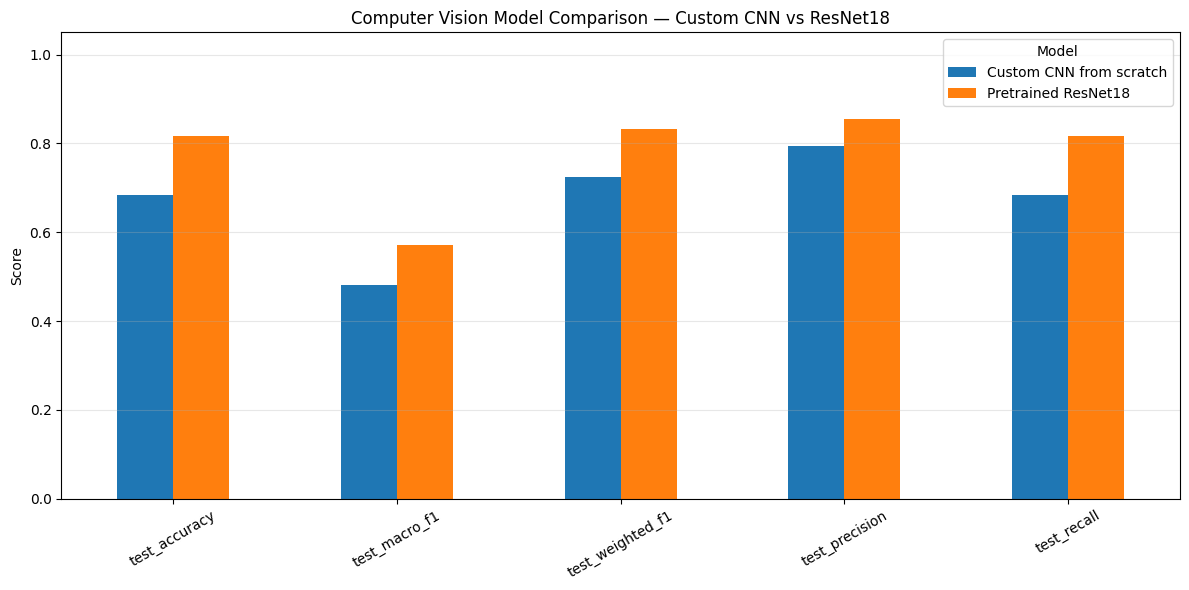

In [33]:
# =========================================================
# MODULE V5.1 — VISUAL MODEL COMPARISON
# =========================================================

import matplotlib.pyplot as plt
import numpy as np

metrics_to_plot = [
    "test_accuracy",
    "test_macro_f1",
    "test_weighted_f1",
    "test_precision",
    "test_recall"
]

plot_df = df_model_comparison.set_index("model")[metrics_to_plot]

ax = plot_df.T.plot(
    kind="bar",
    figsize=(12, 6),
    rot=30
)

plt.title("Computer Vision Model Comparison — Custom CNN vs ResNet18")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

In [34]:
# =========================================================
# MODULE V5.2 — SELECT BEST COMPUTER VISION MODEL
# =========================================================

# We select the model using weighted F1 because the dataset is imbalanced.
best_model_row = df_model_comparison.sort_values(
    by="test_weighted_f1",
    ascending=False
).iloc[0]

best_cv_model_name = best_model_row["model"]
best_cv_model_type = best_model_row["model_type"]
best_cv_model_path = best_model_row["model_path"]

print("=" * 80)
print("BEST COMPUTER VISION MODEL")
print("=" * 80)

print("Best model:", best_cv_model_name)
print("Model type:", best_cv_model_type)
print("Model path:", best_cv_model_path)

print("\nReason:")
print(
    "The best model is selected based on weighted F1 because the page-type dataset "
    "is highly imbalanced and content_page dominates the distribution."
)

BEST COMPUTER VISION MODEL
Best model: Pretrained ResNet18
Model type: pretrained
Model path: /kaggle/working/v4_resnet18_page_classifier.pt

Reason:
The best model is selected based on weighted F1 because the page-type dataset is highly imbalanced and content_page dominates the distribution.


In [35]:
# =========================================================
# MODULE V5.3 — GENERATE MODEL COMPARISON SUMMARY TEXT
# =========================================================

cnn_row = df_model_comparison[df_model_comparison["model"] == "Custom CNN from scratch"].iloc[0]
resnet_row = df_model_comparison[df_model_comparison["model"] == "Pretrained ResNet18"].iloc[0]

accuracy_gain = round(resnet_row["test_accuracy"] - cnn_row["test_accuracy"], 4)
macro_f1_gain = round(resnet_row["test_macro_f1"] - cnn_row["test_macro_f1"], 4)
weighted_f1_gain = round(resnet_row["test_weighted_f1"] - cnn_row["test_weighted_f1"], 4)

comparison_summary = f"""
Computer Vision model comparison summary:

The custom CNN from scratch achieved:
- Accuracy: {cnn_row["test_accuracy"]}
- Macro F1: {cnn_row["test_macro_f1"]}
- Weighted F1: {cnn_row["test_weighted_f1"]}

The pretrained ResNet18 achieved:
- Accuracy: {resnet_row["test_accuracy"]}
- Macro F1: {resnet_row["test_macro_f1"]}
- Weighted F1: {resnet_row["test_weighted_f1"]}

Compared with the custom CNN, ResNet18 improved:
- Accuracy by {accuracy_gain}
- Macro F1 by {macro_f1_gain}
- Weighted F1 by {weighted_f1_gain}

Conclusion:
The pretrained ResNet18 model is selected as the best Computer Vision model for SRS page image classification. It will be used as the vision branch output for downstream fusion with the NLP requirement intelligence pipeline.
"""

print(comparison_summary)

summary_path = "/kaggle/working/v5_cv_model_comparison_summary.txt"

with open(summary_path, "w") as f:
    f.write(comparison_summary)

print("Saved:", summary_path)


Computer Vision model comparison summary:

The custom CNN from scratch achieved:
- Accuracy: 0.6832
- Macro F1: 0.4805
- Weighted F1: 0.725

The pretrained ResNet18 achieved:
- Accuracy: 0.8162
- Macro F1: 0.5711
- Weighted F1: 0.8314

Compared with the custom CNN, ResNet18 improved:
- Accuracy by 0.133
- Macro F1 by 0.0906
- Weighted F1 by 0.1064

Conclusion:
The pretrained ResNet18 model is selected as the best Computer Vision model for SRS page image classification. It will be used as the vision branch output for downstream fusion with the NLP requirement intelligence pipeline.

Saved: /kaggle/working/v5_cv_model_comparison_summary.txt


In [36]:
# =========================================================
# MODULE V5.4 — SAVE FINAL CV EVALUATION PACKAGE
# =========================================================

cv_outputs = {
    "custom_cnn_history": "/kaggle/working/v3_custom_cnn_training_history.csv",
    "custom_cnn_test_predictions": "/kaggle/working/v3_custom_cnn_test_predictions.csv",
    "resnet18_history": "/kaggle/working/v4_resnet18_training_history.csv",
    "resnet18_test_predictions": "/kaggle/working/v4_resnet18_test_predictions.csv",
    "model_comparison": "/kaggle/working/v5_cv_model_comparison.csv",
    "comparison_summary": "/kaggle/working/v5_cv_model_comparison_summary.txt",
    "best_model_path": best_cv_model_path
}

df_cv_outputs = pd.DataFrame(
    [{"output_name": k, "path": v} for k, v in cv_outputs.items()]
)

cv_outputs_manifest_path = "/kaggle/working/v5_cv_outputs_manifest.csv"
df_cv_outputs.to_csv(cv_outputs_manifest_path, index=False)

display(df_cv_outputs)

print("Saved:", cv_outputs_manifest_path)

,output_name,path
0,custom_cnn_history,/kaggle/working/v3_custom_cnn_training_history...
1,custom_cnn_test_predictions,/kaggle/working/v3_custom_cnn_test_predictions...
2,resnet18_history,/kaggle/working/v4_resnet18_training_history.csv
3,resnet18_test_predictions,/kaggle/working/v4_resnet18_test_predictions.csv
4,model_comparison,/kaggle/working/v5_cv_model_comparison.csv
5,comparison_summary,/kaggle/working/v5_cv_model_comparison_summary...
6,best_model_path,/kaggle/working/v4_resnet18_page_classifier.pt


Saved: /kaggle/working/v5_cv_outputs_manifest.csv


# MODULE V6 — VISION XAI WITH GRAD-CAM

This module explains the pretrained ResNet18 page classifier using Grad-CAM.

Grad-CAM highlights the visual regions that contribute the most to the model prediction.  
For SRS page classification, this helps understand whether the model focuses on meaningful page layout elements such as titles, dense text blocks, tables of contents, appendix headers, or low-text areas.

In [37]:
# =========================================================
# MODULE V6.0 — LOAD BEST RESNET18 MODEL FOR GRAD-CAM
# =========================================================

import torch
import torch.nn as nn
import torchvision.models as models
from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

resnet_model_path = "/kaggle/working/v4_resnet18_page_classifier.pt"

if not Path(resnet_model_path).exists():
    raise FileNotFoundError(f"Missing ResNet18 model: {resnet_model_path}")

num_classes = len(label2id_page)

# Rebuild architecture
try:
    from torchvision.models import ResNet18_Weights
    resnet_xai_model = models.resnet18(weights=None)
except Exception:
    resnet_xai_model = models.resnet18(weights=None)

in_features = resnet_xai_model.fc.in_features

resnet_xai_model.fc = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(in_features, num_classes)
)

resnet_xai_model.load_state_dict(
    torch.load(resnet_model_path, map_location=device)
)

resnet_xai_model = resnet_xai_model.to(device)
resnet_xai_model.eval()

print("Loaded best ResNet18 model for Grad-CAM.")
print("Classes:", id2label_page)

Device: cpu
Loaded best ResNet18 model for Grad-CAM.
Classes: {0: 'appendix_page', 1: 'content_page', 2: 'cover_page', 3: 'low_text_page', 4: 'toc_page'}


In [38]:
# =========================================================
# MODULE V6.1 — GRAD-CAM IMPLEMENTATION
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
import torch.nn.functional as F

gradcam_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        
        self.activations = None
        self.gradients = None
        
        self.forward_hook = self.target_layer.register_forward_hook(self.save_activation)
        self.backward_hook = self.target_layer.register_full_backward_hook(self.save_gradient)
    
    def save_activation(self, module, input, output):
        self.activations = output.detach()
    
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    
    def generate(self, input_tensor, class_idx=None):
        self.model.zero_grad()
        
        output = self.model(input_tensor)
        probabilities = torch.softmax(output, dim=1)
        
        if class_idx is None:
            class_idx = torch.argmax(probabilities, dim=1).item()
        
        score = output[:, class_idx]
        score.backward()
        
        gradients = self.gradients
        activations = self.activations
        
        weights = gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        
        cam = F.interpolate(
            cam,
            size=(224, 224),
            mode="bilinear",
            align_corners=False
        )
        
        cam = cam.squeeze().cpu().numpy()
        
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        
        predicted_class = torch.argmax(probabilities, dim=1).item()
        confidence = probabilities[0, predicted_class].item()
        
        return cam, predicted_class, confidence, probabilities.detach().cpu().numpy()[0]
    
    def remove_hooks(self):
        self.forward_hook.remove()
        self.backward_hook.remove()


# Last convolutional block of ResNet18
target_layer = resnet_xai_model.layer4[-1]

gradcam = GradCAM(
    model=resnet_xai_model,
    target_layer=target_layer
)

print("Grad-CAM ready.")

Grad-CAM ready.


In [39]:
# =========================================================
# MODULE V6.2 — GRAD-CAM VISUALIZATION HELPERS
# =========================================================

import os
from pathlib import Path

gradcam_output_dir = Path("/kaggle/working/v6_gradcam_outputs")
gradcam_output_dir.mkdir(parents=True, exist_ok=True)

def load_rgb_image(image_path):
    image = Image.open(image_path)
    
    if image.mode in ["P", "LA"]:
        image = image.convert("RGBA")
    
    image = image.convert("RGB")
    return image


def prepare_image_tensor(image_path):
    image = load_rgb_image(image_path)
    input_tensor = gradcam_transform(image).unsqueeze(0).to(device)
    return image, input_tensor


def create_gradcam_overlay(original_image, cam, alpha=0.45):
    image_resized = original_image.resize((224, 224))
    image_np = np.array(image_resized).astype(np.float32) / 255.0
    
    heatmap = plt.cm.jet(cam)[:, :, :3]
    overlay = (1 - alpha) * image_np + alpha * heatmap
    overlay = np.clip(overlay, 0, 1)
    
    return image_np, heatmap, overlay


def save_gradcam_figure(
    original_image,
    cam,
    true_label,
    pred_label,
    confidence,
    output_path
):
    image_np, heatmap, overlay = create_gradcam_overlay(original_image, cam)
    
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 3, 1)
    plt.imshow(image_np)
    plt.title("Original page")
    plt.axis("off")
    
    plt.subplot(1, 3, 2)
    plt.imshow(heatmap)
    plt.title("Grad-CAM heatmap")
    plt.axis("off")
    
    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title(
        f"True: {true_label}\nPred: {pred_label} ({confidence:.3f})"
    )
    plt.axis("off")
    
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

In [40]:
# =========================================================
# MODULE V6.3 — SELECT GRAD-CAM XAI SAMPLES
# =========================================================

import pandas as pd

resnet_pred_path = "/kaggle/working/v4_resnet18_test_predictions.csv"

if Path(resnet_pred_path).exists():
    df_resnet_xai = pd.read_csv(resnet_pred_path)
else:
    df_resnet_xai = df_resnet_test_predictions.copy()

df_resnet_xai["is_correct"] = (
    df_resnet_xai["page_type"] == df_resnet_xai["resnet18_prediction"]
)

print("ResNet18 XAI dataframe shape:", df_resnet_xai.shape)

print("\nCorrect / incorrect distribution:")
print(df_resnet_xai["is_correct"].value_counts())

# Select up to 2 samples per true class
class_samples = (
    df_resnet_xai
    .groupby("page_type", group_keys=False)
    .apply(lambda x: x.sample(n=min(2, len(x)), random_state=42))
    .reset_index(drop=True)
)

# Add some incorrect predictions if available
wrong_samples = (
    df_resnet_xai[df_resnet_xai["is_correct"] == False]
    .sample(n=min(5, len(df_resnet_xai[df_resnet_xai["is_correct"] == False])), random_state=42)
    .reset_index(drop=True)
)

df_gradcam_samples = pd.concat(
    [class_samples, wrong_samples],
    ignore_index=True
).drop_duplicates(subset=["doc_id", "page_num", "image_path"])

df_gradcam_samples = df_gradcam_samples.reset_index(drop=True)

print("Grad-CAM sample shape:", df_gradcam_samples.shape)

display(df_gradcam_samples[
    [
        "doc_id",
        "page_num",
        "page_type",
        "resnet18_prediction",
        "resnet18_confidence",
        "is_correct",
        "image_path"
    ]
])

ResNet18 XAI dataframe shape: (767, 17)

Correct / incorrect distribution:
is_correct
True     626
False    141
Name: count, dtype: int64
Grad-CAM sample shape: (15, 17)


/tmp/ipykernel_19961/4232497649.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(2, len(x)), random_state=42))


,doc_id,page_num,page_type,resnet18_prediction,resnet18_confidence,is_correct,image_path
0,2004 grid bgc,16,appendix_page,appendix_page,0.851171,True,/kaggle/input/datasets/cyrinemejrii/page-image...
1,0000 inventory,31,appendix_page,appendix_page,0.836333,True,/kaggle/input/datasets/cyrinemejrii/page-image...
2,2010 split merge,19,content_page,content_page,0.982219,True,/kaggle/input/datasets/cyrinemejrii/page-image...
3,1999 tcs scanned,67,content_page,content_page,0.982395,True,/kaggle/input/datasets/cyrinemejrii/page-image...
4,2009 library,1,cover_page,cover_page,0.730048,True,/kaggle/input/datasets/cyrinemejrii/page-image...
5,2007 get real 0.2 scanned,1,cover_page,low_text_page,0.711391,False,/kaggle/input/datasets/cyrinemejrii/page-image...
6,1999 tcs,72,low_text_page,low_text_page,0.998233,True,/kaggle/input/datasets/cyrinemejrii/page-image...
7,1999 tcs scanned,109,low_text_page,low_text_page,0.955660,True,/kaggle/input/datasets/cyrinemejrii/page-image...
8,0000 inventory,2,toc_page,toc_page,0.840669,True,/kaggle/input/datasets/cyrinemejrii/page-image...
9,2009 library scanned,2,toc_page,appendix_page,0.441821,False,/kaggle/input/datasets/cyrinemejrii/page-image...


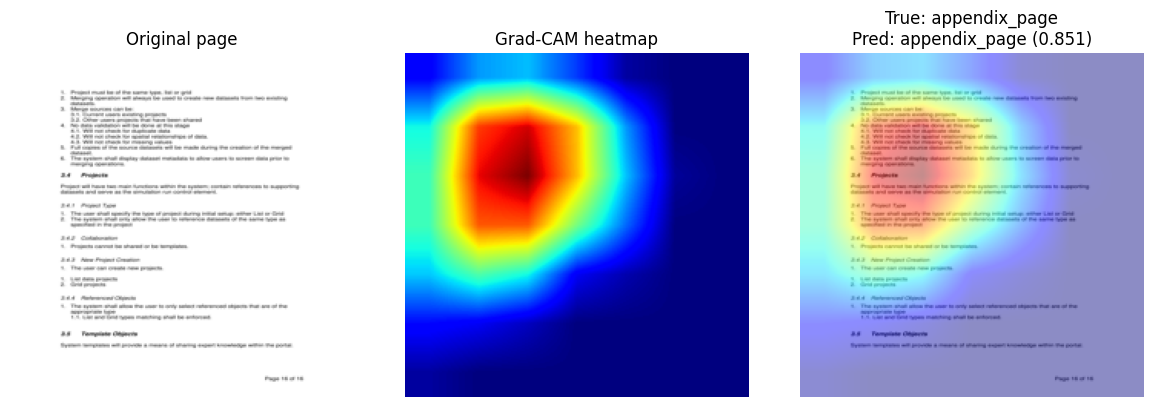

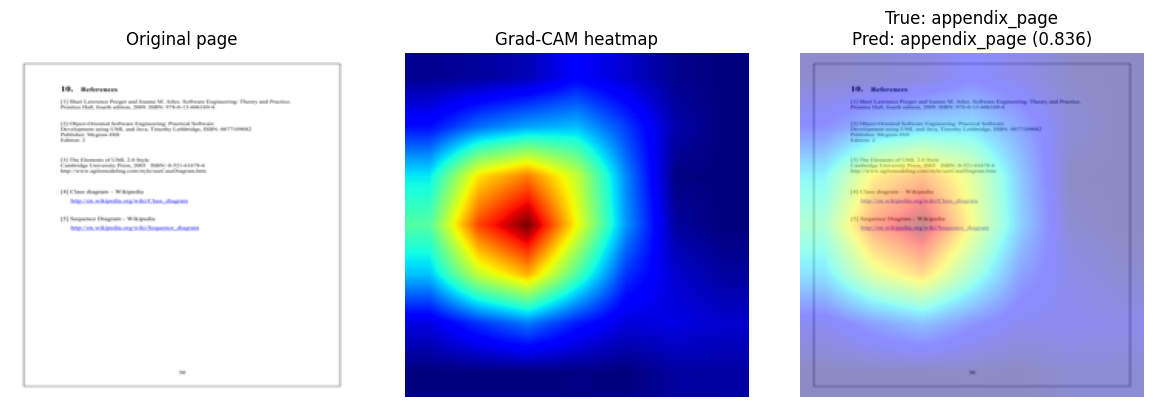

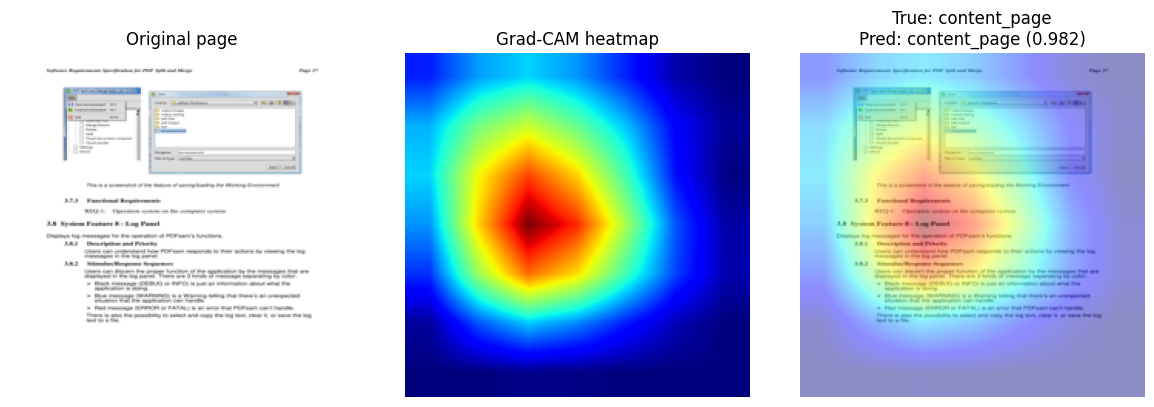

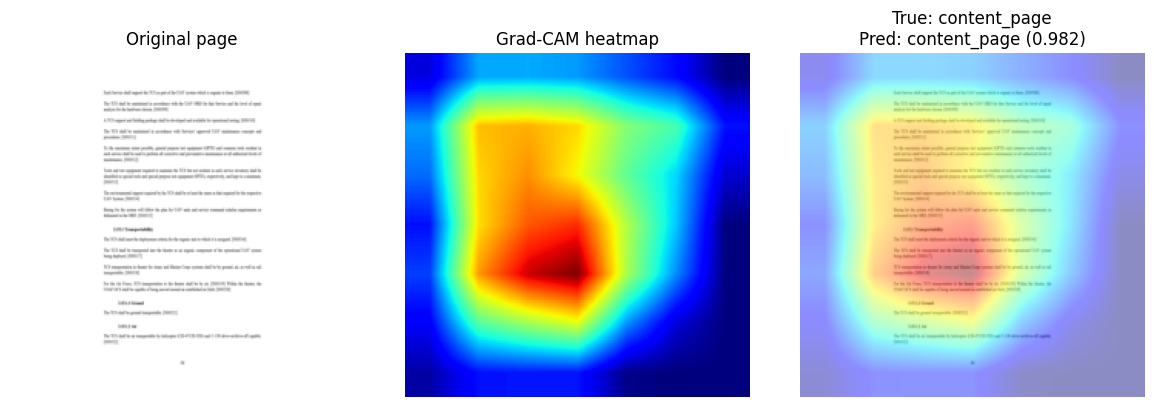

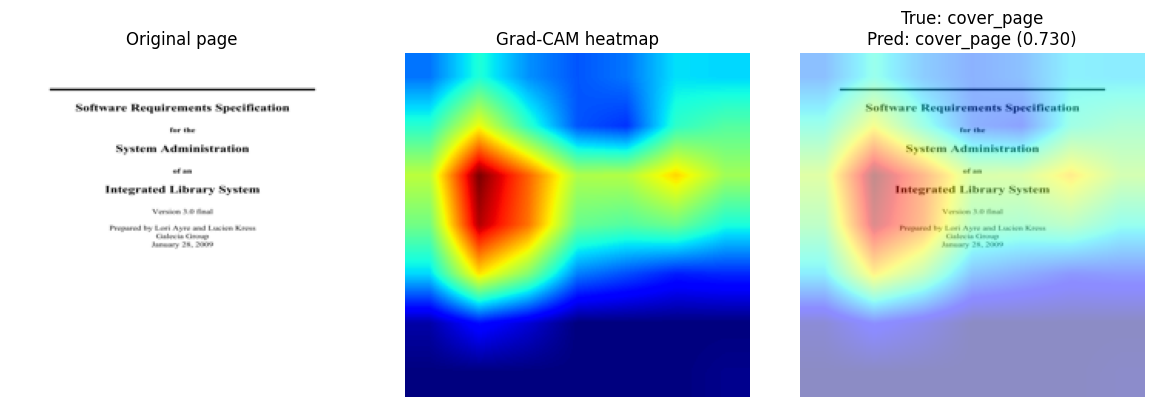

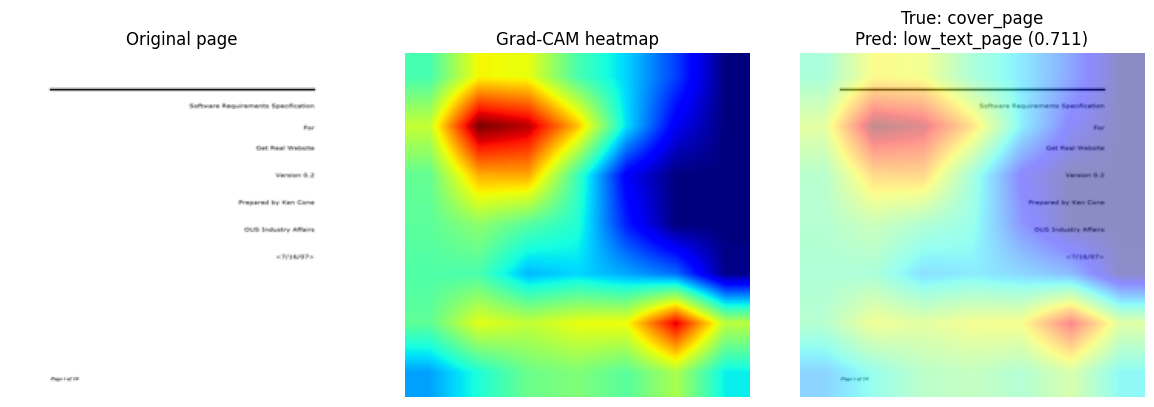

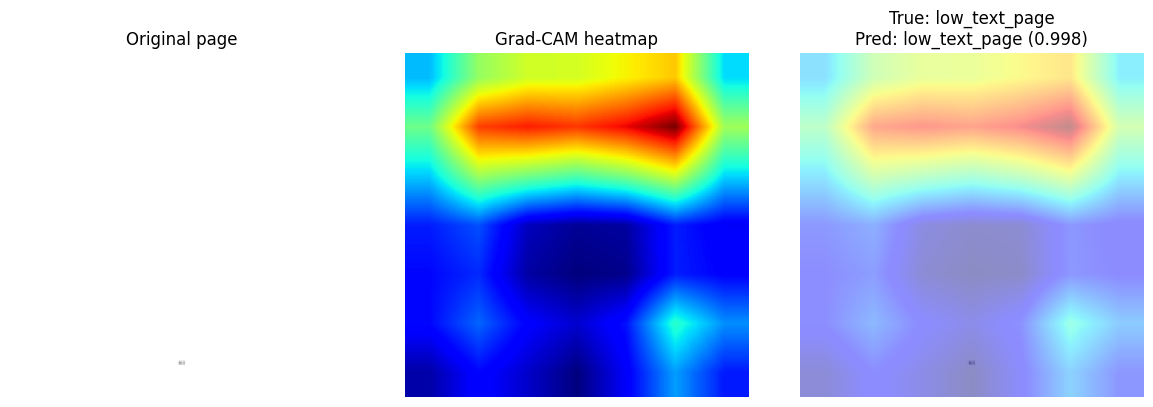

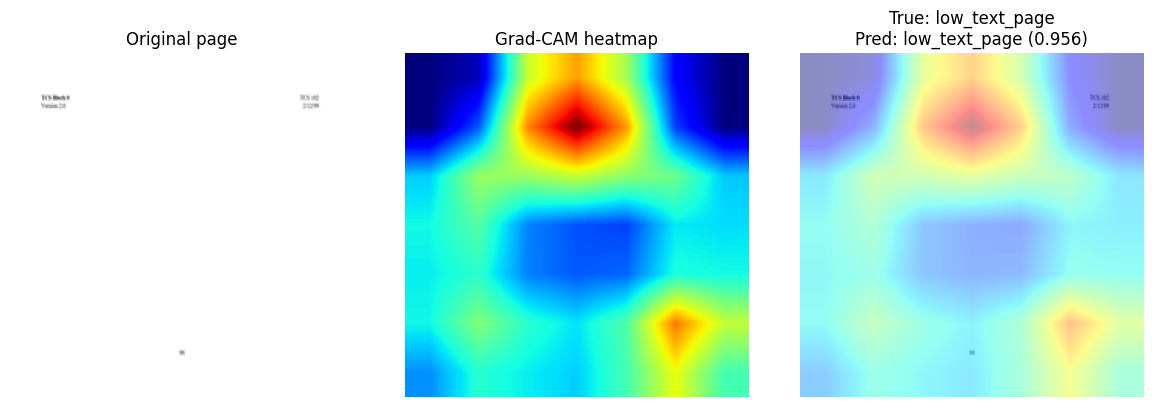

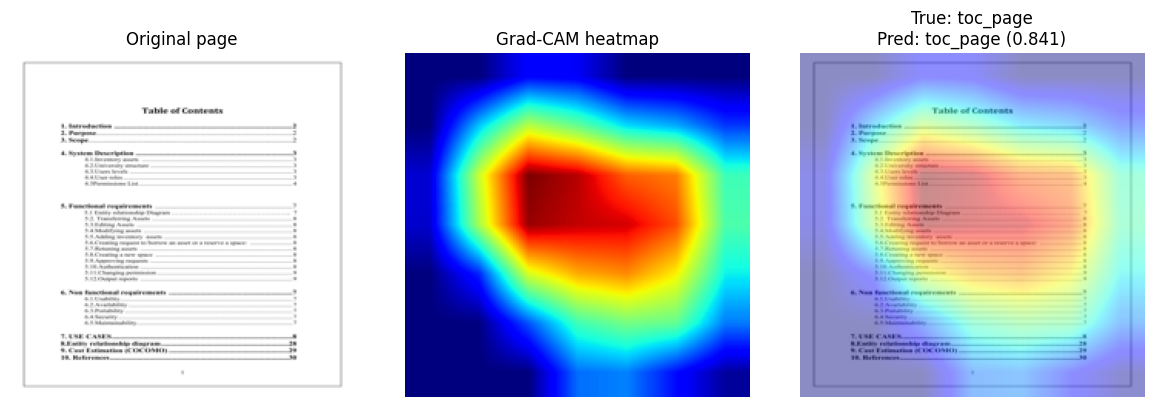

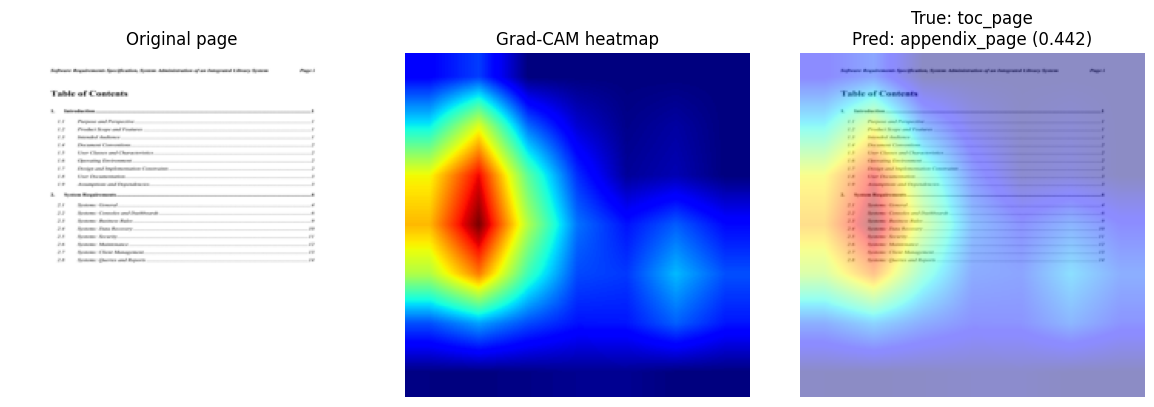

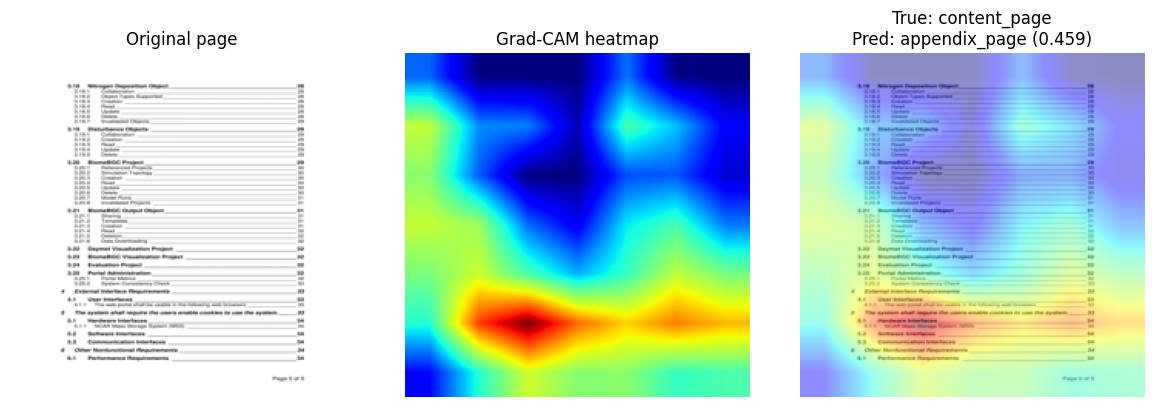

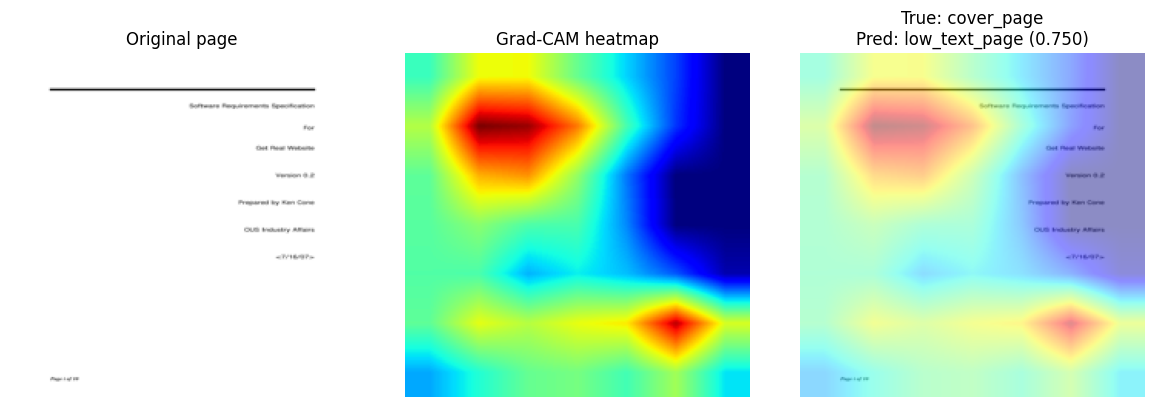

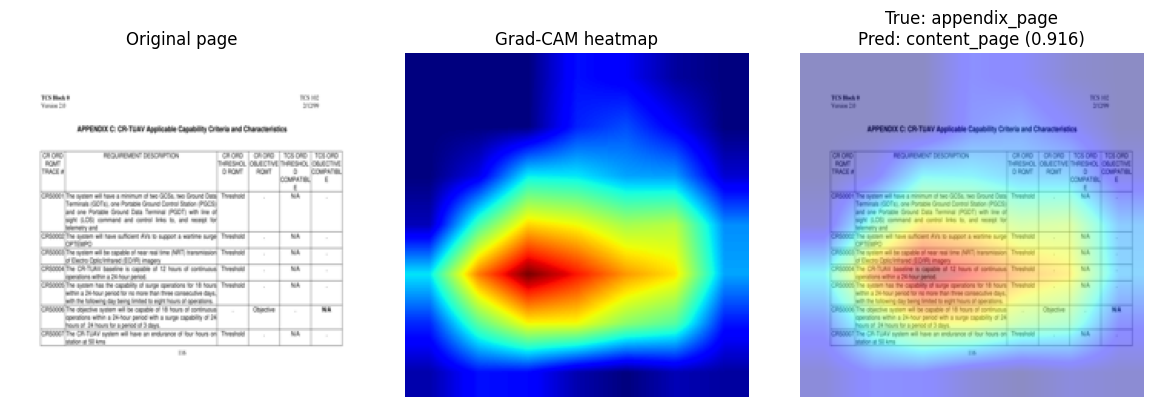

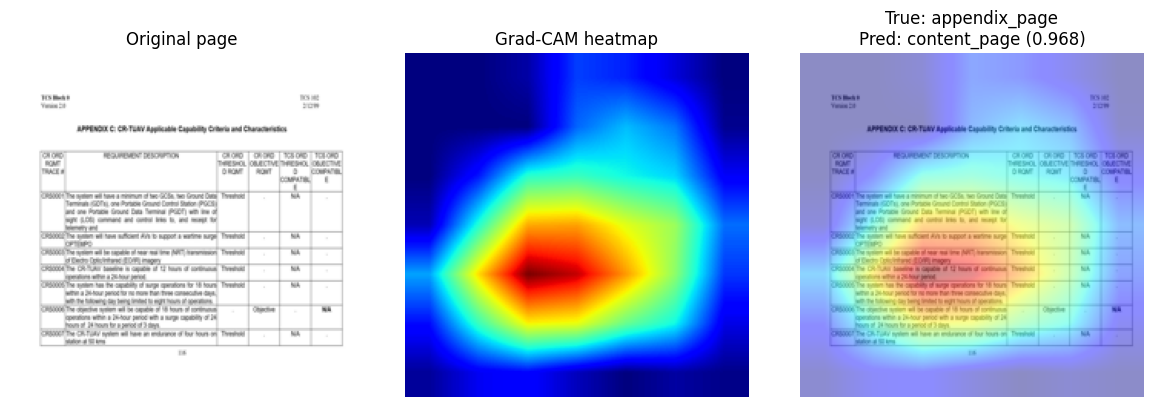

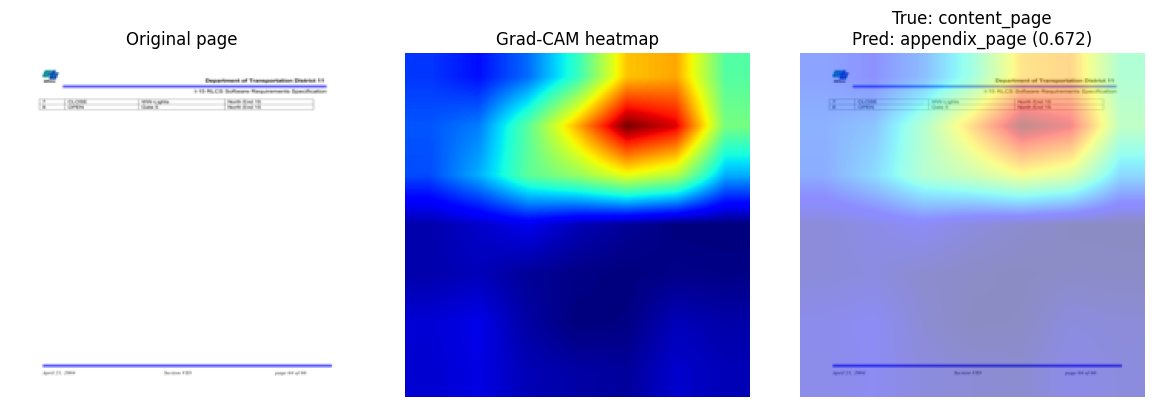

Saved Grad-CAM XAI samples: /kaggle/working/v6_gradcam_xai_samples.csv


,sample_id,doc_id,page_num,image_path,true_page_type,resnet18_prediction,resnet18_confidence,is_correct,gradcam_path,prob_appendix_page,prob_content_page,prob_cover_page,prob_low_text_page,prob_toc_page
0,0,2004 grid bgc,16,/kaggle/input/datasets/cyrinemejrii/page-image...,appendix_page,appendix_page,0.851171,True,/kaggle/working/v6_gradcam_outputs/gradcam_00_...,0.851171,0.147294,2.177684e-05,6.596566e-06,0.001507
1,1,0000 inventory,31,/kaggle/input/datasets/cyrinemejrii/page-image...,appendix_page,appendix_page,0.836332,True,/kaggle/working/v6_gradcam_outputs/gradcam_01_...,0.836332,0.162657,9.720417e-05,6.312387e-04,0.000282
2,2,2010 split merge,19,/kaggle/input/datasets/cyrinemejrii/page-image...,content_page,content_page,0.982219,True,/kaggle/working/v6_gradcam_outputs/gradcam_02_...,0.000079,0.982219,4.143660e-10,4.029833e-09,0.017702
3,3,1999 tcs scanned,67,/kaggle/input/datasets/cyrinemejrii/page-image...,content_page,content_page,0.982395,True,/kaggle/working/v6_gradcam_outputs/gradcam_03_...,0.015646,0.982395,2.104274e-04,4.533932e-04,0.001295
4,4,2009 library,1,/kaggle/input/datasets/cyrinemejrii/page-image...,cover_page,cover_page,0.730048,True,/kaggle/working/v6_gradcam_outputs/gradcam_04_...,0.020203,0.052150,7.300476e-01,1.972991e-01,0.000300
5,5,2007 get real 0.2 scanned,1,/kaggle/input/datasets/cyrinemejrii/page-image...,cover_page,low_text_page,0.711391,False,/kaggle/working/v6_gradcam_outputs/gradcam_05_...,0.013336,0.023154,2.516055e-01,7.113909e-01,0.000513
6,6,1999 tcs,72,/kaggle/input/datasets/cyrinemejrii/page-image...,low_text_page,low_text_page,0.998233,True,/kaggle/working/v6_gradcam_outputs/gradcam_06_...,0.000842,0.000900,6.764495e-06,9.982334e-01,0.000018
7,7,1999 tcs scanned,109,/kaggle/input/datasets/cyrinemejrii/page-image...,low_text_page,low_text_page,0.955660,True,/kaggle/working/v6_gradcam_outputs/gradcam_07_...,0.031873,0.008197,4.517778e-04,9.556600e-01,0.003819
8,8,0000 inventory,2,/kaggle/input/datasets/cyrinemejrii/page-image...,toc_page,toc_page,0.840669,True,/kaggle/working/v6_gradcam_outputs/gradcam_08_...,0.106143,0.052792,1.909296e-04,2.044008e-04,0.840669
9,9,2009 library scanned,2,/kaggle/input/datasets/cyrinemejrii/page-image...,toc_page,appendix_page,0.441821,False,/kaggle/working/v6_gradcam_outputs/gradcam_09_...,0.441821,0.156556,6.412071e-06,3.314251e-04,0.401286


In [41]:
# =========================================================
# MODULE V6.4 — GENERATE GRAD-CAM EXPLANATIONS
# =========================================================

gradcam_rows = []

for idx, row in df_gradcam_samples.iterrows():
    image_path = row["image_path"]
    true_label = row["page_type"]
    
    original_image, input_tensor = prepare_image_tensor(image_path)
    
    cam, pred_id, confidence, probs = gradcam.generate(
        input_tensor=input_tensor,
        class_idx=None
    )
    
    pred_label = id2label_page[int(pred_id)]
    
    output_path = gradcam_output_dir / f"gradcam_{idx:02d}_{true_label}_pred_{pred_label}.png"
    
    save_gradcam_figure(
        original_image=original_image,
        cam=cam,
        true_label=true_label,
        pred_label=pred_label,
        confidence=confidence,
        output_path=output_path
    )
    
    gradcam_row = {
        "sample_id": idx,
        "doc_id": row["doc_id"],
        "page_num": row["page_num"],
        "image_path": image_path,
        "true_page_type": true_label,
        "resnet18_prediction": pred_label,
        "resnet18_confidence": confidence,
        "is_correct": true_label == pred_label,
        "gradcam_path": str(output_path)
    }
    
    for class_idx in range(num_classes):
        class_name = id2label_page[class_idx]
        gradcam_row[f"prob_{class_name}"] = probs[class_idx]
    
    gradcam_rows.append(gradcam_row)

df_gradcam_xai = pd.DataFrame(gradcam_rows)

gradcam_csv_path = "/kaggle/working/v6_gradcam_xai_samples.csv"
df_gradcam_xai.to_csv(gradcam_csv_path, index=False)

print("Saved Grad-CAM XAI samples:", gradcam_csv_path)

display(df_gradcam_xai)

In [42]:
# =========================================================
# MODULE V6.5 — GRAD-CAM INTERPRETATION SUMMARY
# =========================================================

gradcam_summary = f"""
Vision XAI Summary — Grad-CAM

The pretrained ResNet18 page classifier was explained using Grad-CAM.

Grad-CAM highlights the regions of each SRS page image that contributed most to the predicted page type.

Number of explained samples: {len(df_gradcam_xai)}

Classes explained:
{list(id2label_page.values())}

The explanations help verify whether the model is focusing on meaningful visual document structures, such as:
- title blocks for cover pages
- dense paragraph regions for content pages
- appendix headers for appendix pages
- sparse text regions for low-text pages
- structured heading/page-number patterns for table-of-contents pages

These visual explanations support the interpretability requirement of the Computer Vision pipeline.
"""

print(gradcam_summary)

gradcam_summary_path = "/kaggle/working/v6_gradcam_xai_summary.txt"

with open(gradcam_summary_path, "w") as f:
    f.write(gradcam_summary)

print("Saved:", gradcam_summary_path)


Vision XAI Summary — Grad-CAM

The pretrained ResNet18 page classifier was explained using Grad-CAM.

Grad-CAM highlights the regions of each SRS page image that contributed most to the predicted page type.

Number of explained samples: 15

Classes explained:
['appendix_page', 'content_page', 'cover_page', 'low_text_page', 'toc_page']

The explanations help verify whether the model is focusing on meaningful visual document structures, such as:
- title blocks for cover pages
- dense paragraph regions for content pages
- appendix headers for appendix pages
- sparse text regions for low-text pages
- structured heading/page-number patterns for table-of-contents pages

These visual explanations support the interpretability requirement of the Computer Vision pipeline.

Saved: /kaggle/working/v6_gradcam_xai_summary.txt


In [43]:
# =========================================================
# MODULE V6.6 — CLEAN GRAD-CAM HOOKS
# =========================================================

gradcam.remove_hooks()

print("Grad-CAM hooks removed.")

Grad-CAM hooks removed.


# MODULE V7 — FINAL VISION OUTPUT FOR NLP INTEGRATION

This module applies the best Computer Vision model, the pretrained ResNet18, to all available SRS page images.

The output is a page-level vision prediction table that will be used later in the final multimodal pipeline.

The final vision output includes:

- document id
- page number
- image path
- true page type
- predicted page type
- prediction confidence
- probability for each page type
- correctness flag
- split information
- vision quality flag

This file will be merged with the NLP outputs in the final notebook for multimodal requirement quality scoring and final reporting.

In [44]:
# =========================================================
# MODULE V7.0 — LOAD BEST RESNET18 AND PREPARE FULL DATASET
# =========================================================

import torch
import torch.nn as nn
import torchvision.models as models
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

resnet_model_path = "/kaggle/working/v4_resnet18_page_classifier.pt"

if not Path(resnet_model_path).exists():
    raise FileNotFoundError(f"Missing best ResNet18 model: {resnet_model_path}")

num_classes = len(label2id_page)

# Rebuild ResNet18 architecture
resnet_final_model = models.resnet18(weights=None)

in_features = resnet_final_model.fc.in_features

resnet_final_model.fc = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(in_features, num_classes)
)

resnet_final_model.load_state_dict(
    torch.load(resnet_model_path, map_location=device)
)

resnet_final_model = resnet_final_model.to(device)
resnet_final_model.eval()

print("Loaded final ResNet18 vision model.")
print("Classes:", id2label_page)

Device: cpu
Loaded final ResNet18 vision model.
Classes: {0: 'appendix_page', 1: 'content_page', 2: 'cover_page', 3: 'low_text_page', 4: 'toc_page'}


In [45]:
# =========================================================
# MODULE V7.1 — FULL PAGE DATASET AND DATALOADER
# =========================================================

final_eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


class FinalSRSPageVisionDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image_path = row["image_path"]
        label = int(row["page_type_id"])

        image = Image.open(image_path)

        if image.mode in ["P", "LA"]:
            image = image.convert("RGBA")

        image = image.convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return {
            "pixel_values": image,
            "labels": torch.tensor(label, dtype=torch.long),
            "doc_id": row["doc_id"],
            "page_num": int(row["page_num"]),
            "image_path": row["image_path"],
            "true_page_type": row["page_type"],
            "split": row.get("split", "unknown")
        }


df_full_vision = df_cv_dataset.copy().reset_index(drop=True)

full_vision_dataset = FinalSRSPageVisionDataset(
    df_full_vision,
    transform=final_eval_transform
)

full_vision_loader = DataLoader(
    full_vision_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

print("Full vision dataset size:", len(full_vision_dataset))
print("Full vision batches:", len(full_vision_loader))

Full vision dataset size: 5666
Full vision batches: 178


In [46]:
# =========================================================
# MODULE V7.2 — PREDICT ALL PAGES WITH RESNET18
# =========================================================

from tqdm.auto import tqdm

all_doc_ids = []
all_page_nums = []
all_image_paths = []
all_true_labels = []
all_splits = []

all_pred_ids = []
all_pred_labels = []
all_confidences = []
all_probs = []

resnet_final_model.eval()

with torch.no_grad():
    for batch in tqdm(full_vision_loader, desc="Predicting all pages"):
        images = batch["pixel_values"].to(device)

        outputs = resnet_final_model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        batch_probs = probs.detach().cpu().numpy()
        batch_preds = preds.detach().cpu().numpy()
        batch_confidences = batch_probs.max(axis=1)

        all_doc_ids.extend(batch["doc_id"])
        all_page_nums.extend(batch["page_num"].numpy().tolist())
        all_image_paths.extend(batch["image_path"])
        all_true_labels.extend(batch["true_page_type"])
        all_splits.extend(batch["split"])

        all_pred_ids.extend(batch_preds.tolist())
        all_pred_labels.extend([id2label_page[int(i)] for i in batch_preds])
        all_confidences.extend(batch_confidences.tolist())
        all_probs.extend(batch_probs)

all_probs = np.array(all_probs)

print("Total predictions:", len(all_pred_labels))
print("Probability matrix shape:", all_probs.shape)

Predicting all pages:   0%|          | 0/178 [00:00<?, ?it/s]

Total predictions: 5666
Probability matrix shape: (5666, 5)


In [47]:
# =========================================================
# MODULE V7.3 — BUILD FINAL VISION PREDICTION TABLE
# =========================================================

df_v7_vision_predictions = pd.DataFrame({
    "doc_id": all_doc_ids,
    "page_num": all_page_nums,
    "image_path": all_image_paths,
    "split": all_splits,
    "true_page_type": all_true_labels,
    "vision_model_name": "pretrained_resnet18",
    "vision_pred_id": all_pred_ids,
    "vision_page_type": all_pred_labels,
    "vision_confidence": all_confidences
})

df_v7_vision_predictions["vision_is_correct"] = (
    df_v7_vision_predictions["true_page_type"] ==
    df_v7_vision_predictions["vision_page_type"]
)

for class_idx in range(num_classes):
    class_name = id2label_page[class_idx]
    df_v7_vision_predictions[f"vision_prob_{class_name}"] = all_probs[:, class_idx]

def vision_quality_flag(row):
    conf = float(row["vision_confidence"])

    if conf >= 0.85:
        return "high_confidence_visual_prediction"
    elif conf >= 0.60:
        return "medium_confidence_visual_prediction"
    else:
        return "low_confidence_visual_prediction"

df_v7_vision_predictions["vision_quality_flag"] = df_v7_vision_predictions.apply(
    vision_quality_flag,
    axis=1
)

print("Final vision predictions shape:", df_v7_vision_predictions.shape)

print("\nVision predicted page type distribution:")
print(df_v7_vision_predictions["vision_page_type"].value_counts())

print("\nVision confidence summary:")
display(df_v7_vision_predictions["vision_confidence"].describe())

print("\nVision quality flag distribution:")
print(df_v7_vision_predictions["vision_quality_flag"].value_counts())

print("\nVision correctness:")
print(df_v7_vision_predictions["vision_is_correct"].value_counts())

display(df_v7_vision_predictions.head(30))

Final vision predictions shape: (5666, 16)

Vision predicted page type distribution:
vision_page_type
content_page     4083
appendix_page     824
toc_page          415
low_text_page     248
cover_page         96
Name: count, dtype: int64

Vision confidence summary:


count    5666.000000
mean        0.878057
std         0.150817
min         0.331852
25%         0.798333
50%         0.952828
75%         0.993461
max         1.000000
Name: vision_confidence, dtype: float64


Vision quality flag distribution:
vision_quality_flag
high_confidence_visual_prediction      3937
medium_confidence_visual_prediction    1254
low_confidence_visual_prediction        475
Name: count, dtype: int64

Vision correctness:
vision_is_correct
True     4940
False     726
Name: count, dtype: int64


,doc_id,page_num,image_path,split,true_page_type,vision_model_name,vision_pred_id,vision_page_type,vision_confidence,vision_is_correct,vision_prob_appendix_page,vision_prob_content_page,vision_prob_cover_page,vision_prob_low_text_page,vision_prob_toc_page,vision_quality_flag
0,0000 cctns,1,/kaggle/input/datasets/cyrinemejrii/page-image...,unknown,cover_page,pretrained_resnet18,2,cover_page,0.998174,True,0.000098,0.000824,9.981742e-01,8.936492e-04,0.000011,high_confidence_visual_prediction
1,0000 cctns,2,/kaggle/input/datasets/cyrinemejrii/page-image...,unknown,toc_page,pretrained_resnet18,1,content_page,0.822459,False,0.137331,0.822459,2.104272e-05,6.052756e-05,0.040128,medium_confidence_visual_prediction
2,0000 cctns,3,/kaggle/input/datasets/cyrinemejrii/page-image...,unknown,content_page,pretrained_resnet18,1,content_page,0.758445,True,0.239660,0.758445,1.254702e-04,1.022061e-04,0.001667,medium_confidence_visual_prediction
3,0000 cctns,4,/kaggle/input/datasets/cyrinemejrii/page-image...,unknown,content_page,pretrained_resnet18,0,appendix_page,0.617763,False,0.617763,0.373769,1.445217e-06,1.121706e-06,0.008465,medium_confidence_visual_prediction
4,0000 cctns,5,/kaggle/input/datasets/cyrinemejrii/page-image...,unknown,content_page,pretrained_resnet18,1,content_page,0.944118,True,0.054365,0.944118,7.259221e-06,4.217300e-06,0.001506,high_confidence_visual_prediction
5,0000 cctns,6,/kaggle/input/datasets/cyrinemejrii/page-image...,unknown,content_page,pretrained_resnet18,1,content_page,0.664405,True,0.321971,0.664405,1.336178e-03,8.589703e-03,0.003698,medium_confidence_visual_prediction
6,0000 cctns,7,/kaggle/input/datasets/cyrinemejrii/page-image...,unknown,toc_page,pretrained_resnet18,1,content_page,0.646964,False,0.202750,0.646964,1.268401e-04,5.444127e-04,0.149614,medium_confidence_visual_prediction
7,0000 cctns,8,/kaggle/input/datasets/cyrinemejrii/page-image...,unknown,content_page,pretrained_resnet18,1,content_page,0.921359,True,0.038727,0.921359,1.454476e-06,7.306720e-06,0.039905,high_confidence_visual_prediction
8,0000 cctns,9,/kaggle/input/datasets/cyrinemejrii/page-image...,unknown,toc_page,pretrained_resnet18,1,content_page,0.809588,False,0.133194,0.809588,4.587419e-07,1.034519e-05,0.057208,medium_confidence_visual_prediction
9,0000 cctns,10,/kaggle/input/datasets/cyrinemejrii/page-image...,unknown,content_page,pretrained_resnet18,1,content_page,0.592405,True,0.366073,0.592405,4.033790e-05,3.152039e-04,0.041166,low_confidence_visual_prediction


In [48]:
# =========================================================
# MODULE V7.3B — FIX SPLIT INFORMATION IN FINAL VISION TABLE
# =========================================================

df_train_split_map = df_train_cv.copy()
df_train_split_map["split"] = "train"

df_val_split_map = df_val_cv.copy()
df_val_split_map["split"] = "validation"

df_test_split_map = df_test_cv.copy()
df_test_split_map["split"] = "test"

df_split_map = pd.concat(
    [df_train_split_map, df_val_split_map, df_test_split_map],
    ignore_index=True
)

df_split_map = df_split_map[
    ["doc_id", "page_num", "image_path", "split"]
].drop_duplicates()

# Remove old split column if it is unknown or unreliable
if "split" in df_v7_vision_predictions.columns:
    df_v7_vision_predictions = df_v7_vision_predictions.drop(columns=["split"])

df_v7_vision_predictions = df_v7_vision_predictions.merge(
    df_split_map,
    on=["doc_id", "page_num", "image_path"],
    how="left"
)

df_v7_vision_predictions["split"] = df_v7_vision_predictions["split"].fillna("unknown")

print("Split distribution after fix:")
print(df_v7_vision_predictions["split"].value_counts())

display(df_v7_vision_predictions.head(20))

Split distribution after fix:
split
train         4255
test           767
validation     644
Name: count, dtype: int64


,doc_id,page_num,image_path,true_page_type,vision_model_name,vision_pred_id,vision_page_type,vision_confidence,vision_is_correct,vision_prob_appendix_page,vision_prob_content_page,vision_prob_cover_page,vision_prob_low_text_page,vision_prob_toc_page,vision_quality_flag,split
0,0000 cctns,1,/kaggle/input/datasets/cyrinemejrii/page-image...,cover_page,pretrained_resnet18,2,cover_page,0.998174,True,0.000098,0.000824,9.981742e-01,8.936492e-04,0.000011,high_confidence_visual_prediction,validation
1,0000 cctns,2,/kaggle/input/datasets/cyrinemejrii/page-image...,toc_page,pretrained_resnet18,1,content_page,0.822459,False,0.137331,0.822459,2.104272e-05,6.052756e-05,0.040128,medium_confidence_visual_prediction,validation
2,0000 cctns,3,/kaggle/input/datasets/cyrinemejrii/page-image...,content_page,pretrained_resnet18,1,content_page,0.758445,True,0.239660,0.758445,1.254702e-04,1.022061e-04,0.001667,medium_confidence_visual_prediction,validation
3,0000 cctns,4,/kaggle/input/datasets/cyrinemejrii/page-image...,content_page,pretrained_resnet18,0,appendix_page,0.617763,False,0.617763,0.373769,1.445217e-06,1.121706e-06,0.008465,medium_confidence_visual_prediction,validation
4,0000 cctns,5,/kaggle/input/datasets/cyrinemejrii/page-image...,content_page,pretrained_resnet18,1,content_page,0.944118,True,0.054365,0.944118,7.259221e-06,4.217300e-06,0.001506,high_confidence_visual_prediction,validation
5,0000 cctns,6,/kaggle/input/datasets/cyrinemejrii/page-image...,content_page,pretrained_resnet18,1,content_page,0.664405,True,0.321971,0.664405,1.336178e-03,8.589703e-03,0.003698,medium_confidence_visual_prediction,validation
6,0000 cctns,7,/kaggle/input/datasets/cyrinemejrii/page-image...,toc_page,pretrained_resnet18,1,content_page,0.646964,False,0.202750,0.646964,1.268401e-04,5.444127e-04,0.149614,medium_confidence_visual_prediction,validation
7,0000 cctns,8,/kaggle/input/datasets/cyrinemejrii/page-image...,content_page,pretrained_resnet18,1,content_page,0.921359,True,0.038727,0.921359,1.454476e-06,7.306720e-06,0.039905,high_confidence_visual_prediction,validation
8,0000 cctns,9,/kaggle/input/datasets/cyrinemejrii/page-image...,toc_page,pretrained_resnet18,1,content_page,0.809588,False,0.133194,0.809588,4.587419e-07,1.034519e-05,0.057208,medium_confidence_visual_prediction,validation
9,0000 cctns,10,/kaggle/input/datasets/cyrinemejrii/page-image...,content_page,pretrained_resnet18,1,content_page,0.592405,True,0.366073,0.592405,4.033790e-05,3.152039e-04,0.041166,low_confidence_visual_prediction,validation


In [49]:
# =========================================================
# MODULE V7.4 — DOCUMENT-LEVEL VISION SUMMARY
# =========================================================

df_v7_document_vision_summary = (
    df_v7_vision_predictions
    .groupby("doc_id")
    .agg(
        total_pages=("page_num", "count"),
        avg_vision_confidence=("vision_confidence", "mean"),
        correct_visual_pages=("vision_is_correct", "sum"),
        cover_pages_pred=("vision_page_type", lambda x: (x == "cover_page").sum()),
        toc_pages_pred=("vision_page_type", lambda x: (x == "toc_page").sum()),
        content_pages_pred=("vision_page_type", lambda x: (x == "content_page").sum()),
        appendix_pages_pred=("vision_page_type", lambda x: (x == "appendix_page").sum()),
        low_text_pages_pred=("vision_page_type", lambda x: (x == "low_text_page").sum()),
        low_confidence_pages=("vision_quality_flag", lambda x: (x == "low_confidence_visual_prediction").sum())
    )
    .reset_index()
)

df_v7_document_vision_summary["vision_accuracy_proxy"] = (
    df_v7_document_vision_summary["correct_visual_pages"] /
    df_v7_document_vision_summary["total_pages"].replace(0, np.nan)
).fillna(0).round(3)

df_v7_document_vision_summary["avg_vision_confidence"] = (
    df_v7_document_vision_summary["avg_vision_confidence"].round(4)
)

def document_vision_quality(row):
    if row["avg_vision_confidence"] >= 0.80 and row["low_confidence_pages"] == 0:
        return "strong_visual_structure"
    elif row["avg_vision_confidence"] >= 0.60:
        return "moderate_visual_structure"
    else:
        return "weak_visual_structure"

df_v7_document_vision_summary["document_vision_quality_flag"] = (
    df_v7_document_vision_summary.apply(document_vision_quality, axis=1)
)

print("Document-level vision summary shape:", df_v7_document_vision_summary.shape)

display(df_v7_document_vision_summary.head(30))

print("\nDocument vision quality distribution:")
print(df_v7_document_vision_summary["document_vision_quality_flag"].value_counts())

Document-level vision summary shape: (124, 12)


,doc_id,total_pages,avg_vision_confidence,correct_visual_pages,cover_pages_pred,toc_pages_pred,content_pages_pred,appendix_pages_pred,low_text_pages_pred,low_confidence_pages,vision_accuracy_proxy,document_vision_quality_flag
0,0000 cctns,19,0.7431,14,1,0,16,2,0,4,0.737,moderate_visual_structure
1,0000 cctns scanned,19,0.7966,17,1,1,17,0,0,1,0.895,moderate_visual_structure
2,0000 gamma j,44,0.8798,37,1,1,20,12,10,3,0.841,moderate_visual_structure
3,0000 gamma j scanned,44,0.8651,28,1,1,20,11,11,3,0.636,moderate_visual_structure
4,0000 inventory,31,0.8988,29,1,2,27,1,0,1,0.935,moderate_visual_structure
5,0000 inventory scanned,31,0.8942,29,1,2,28,0,0,0,0.935,strong_visual_structure
6,1995 gemini,96,0.9702,92,2,2,86,2,4,3,0.958,moderate_visual_structure
7,1995 gemini scanned,96,0.9689,92,2,2,86,2,4,2,0.958,moderate_visual_structure
8,1998 themas,40,0.9444,39,1,6,29,4,0,1,0.975,moderate_visual_structure
9,1998 themas scanned,40,0.9621,39,1,6,29,4,0,0,0.975,strong_visual_structure



Document vision quality distribution:
document_vision_quality_flag
moderate_visual_structure    107
strong_visual_structure       17
Name: count, dtype: int64


In [50]:
# =========================================================
# MODULE V7.5 — SAVE FINAL VISION OUTPUTS
# =========================================================

v7_predictions_path = "/kaggle/working/v7_page_vision_predictions.csv"
v7_document_summary_path = "/kaggle/working/v7_document_vision_summary.csv"

df_v7_vision_predictions.to_csv(v7_predictions_path, index=False)
df_v7_document_vision_summary.to_csv(v7_document_summary_path, index=False)

print("Saved:", v7_predictions_path)
print("Saved:", v7_document_summary_path)

print("\nV7 page vision predictions shape:", df_v7_vision_predictions.shape)
print("V7 document vision summary shape:", df_v7_document_vision_summary.shape)

Saved: /kaggle/working/v7_page_vision_predictions.csv
Saved: /kaggle/working/v7_document_vision_summary.csv

V7 page vision predictions shape: (5666, 16)
V7 document vision summary shape: (124, 12)


In [51]:
# =========================================================
# MODULE V7.6 — FINAL COMPUTER VISION NOTEBOOK SUMMARY
# =========================================================

cv_final_summary = f"""
Final Computer Vision Pipeline Summary

Task:
SRS page image classification.

Input:
Page image extracted from SRS PDF documents.

Output classes:
{list(id2label_page.values())}

Dataset:
- Total page images: {len(df_v7_vision_predictions)}
- Unique documents: {df_v7_vision_predictions["doc_id"].nunique()}

Models:
1. Custom CNN from scratch
2. Pretrained ResNet18

Best model:
{best_cv_model_name}

Reason:
The pretrained ResNet18 achieved the best weighted F1 score and was selected as the final Computer Vision model.

XAI:
Grad-CAM was used to explain the pretrained ResNet18 predictions.

Final outputs:
- /kaggle/working/v7_page_vision_predictions.csv
- /kaggle/working/v7_document_vision_summary.csv

These outputs will be used in the final multimodal notebook to integrate Computer Vision page understanding with NLP requirement intelligence.
"""

print(cv_final_summary)

cv_final_summary_path = "/kaggle/working/v7_final_cv_pipeline_summary.txt"

with open(cv_final_summary_path, "w") as f:
    f.write(cv_final_summary)

print("Saved:", cv_final_summary_path)


Final Computer Vision Pipeline Summary

Task:
SRS page image classification.

Input:
Page image extracted from SRS PDF documents.

Output classes:
['appendix_page', 'content_page', 'cover_page', 'low_text_page', 'toc_page']

Dataset:
- Total page images: 5666
- Unique documents: 124

Models:
1. Custom CNN from scratch
2. Pretrained ResNet18

Best model:
Pretrained ResNet18

Reason:
The pretrained ResNet18 achieved the best weighted F1 score and was selected as the final Computer Vision model.

XAI:
Grad-CAM was used to explain the pretrained ResNet18 predictions.

Final outputs:
- /kaggle/working/v7_page_vision_predictions.csv
- /kaggle/working/v7_document_vision_summary.csv

These outputs will be used in the final multimodal notebook to integrate Computer Vision page understanding with NLP requirement intelligence.

Saved: /kaggle/working/v7_final_cv_pipeline_summary.txt


In [52]:
# ============================================================
# CREATE NOTEBOOK 3 CV DEPLOYMENT BUNDLE
# ============================================================

import json
import shutil
from pathlib import Path
import pandas as pd

print("=" * 80)
print("CREATE NOTEBOOK 3 CV DEPLOYMENT BUNDLE")
print("=" * 80)

# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------

WORK_DIR = Path("/kaggle/working")
BUNDLE_DIR = WORK_DIR / "notebook3_cv_deployment_bundle"

MODELS_DIR = BUNDLE_DIR / "models"
CONFIGS_DIR = BUNDLE_DIR / "configs"
OUTPUTS_DIR = BUNDLE_DIR / "sample_outputs"

for d in [MODELS_DIR, CONFIGS_DIR, OUTPUTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 2. Required final CV model
# ------------------------------------------------------------

resnet_model_path = WORK_DIR / "v4_resnet18_page_classifier.pt"

if not resnet_model_path.exists():
    raise FileNotFoundError(
        "Missing v4_resnet18_page_classifier.pt. "
        "Run Notebook 3 ResNet18 training/evaluation first."
    )

shutil.copy2(resnet_model_path, MODELS_DIR / "v4_resnet18_page_classifier.pt")
print("Copied model:")
print("->", MODELS_DIR / "v4_resnet18_page_classifier.pt")

# ------------------------------------------------------------
# 3. Label mappings
# ------------------------------------------------------------
# Use notebook variables if they exist, otherwise fallback to final known mapping.

try:
    label2id = label2id_page
except NameError:
    label2id = {
        "appendix_page": 0,
        "content_page": 1,
        "cover_page": 2,
        "low_text_page": 3,
        "toc_page": 4,
    }

try:
    id2label = id2label_page
except NameError:
    id2label = {str(v): k for k, v in label2id.items()}

# Convert keys to strings for JSON compatibility
label2id_json = {str(k): int(v) for k, v in label2id.items()}
id2label_json = {str(k): str(v) for k, v in id2label.items()}

with open(CONFIGS_DIR / "cv_page_label2id.json", "w", encoding="utf-8") as f:
    json.dump(label2id_json, f, indent=2)

with open(CONFIGS_DIR / "cv_page_id2label.json", "w", encoding="utf-8") as f:
    json.dump(id2label_json, f, indent=2)

print("Saved label configs:")
print("->", CONFIGS_DIR / "cv_page_label2id.json")
print("->", CONFIGS_DIR / "cv_page_id2label.json")

# ------------------------------------------------------------
# 4. CV classifier deployment config
# ------------------------------------------------------------

cv_config = {
    "model_name": "pretrained_resnet18_page_classifier",
    "architecture": "resnet18",
    "weights_file": "v4_resnet18_page_classifier.pt",
    "task": "SRS page image classification",
    "input_type": "page_image",
    "image_size": 224,
    "num_classes": 5,
    "classes": label2id_json,
    "id2label": id2label_json,
    "preprocessing": {
        "resize": [224, 224],
        "convert": "RGB",
        "normalization_mean": [0.485, 0.456, 0.406],
        "normalization_std": [0.229, 0.224, 0.225]
    },
    "output": {
        "vision_page_type": "predicted page class",
        "vision_confidence": "maximum softmax probability",
        "vision_probabilities": "probability per page class"
    },
    "page_classes": [
        "appendix_page",
        "content_page",
        "cover_page",
        "low_text_page",
        "toc_page"
    ],
    "selected_as_final_model": True,
    "reason": "Pretrained ResNet18 achieved the best weighted F1 score and was selected as the final Computer Vision model."
}

with open(CONFIGS_DIR / "cv_page_classifier_config.json", "w", encoding="utf-8") as f:
    json.dump(cv_config, f, indent=2)

print("Saved CV config:")
print("->", CONFIGS_DIR / "cv_page_classifier_config.json")

# ------------------------------------------------------------
# 5. Optional useful outputs
# ------------------------------------------------------------

optional_files = [
    "v5_cv_model_comparison.csv",
    "v5_cv_model_comparison_summary.txt",
    "v6_gradcam_xai_samples.csv",
    "v6_gradcam_xai_summary.txt",
    "v7_page_vision_predictions.csv",
    "v7_document_vision_summary.csv",
    "v7_final_cv_pipeline_summary.txt",
]

copied_outputs = []

for filename in optional_files:
    src = WORK_DIR / filename
    if src.exists():
        shutil.copy2(src, OUTPUTS_DIR / filename)
        copied_outputs.append(filename)
        print("Copied output:")
        print("->", OUTPUTS_DIR / filename)
    else:
        print("Missing optional output:", filename)

# Optional Grad-CAM folder
gradcam_dir = WORK_DIR / "v6_gradcam_outputs"
if gradcam_dir.exists():
    shutil.copytree(
        gradcam_dir,
        OUTPUTS_DIR / "v6_gradcam_outputs",
        dirs_exist_ok=True
    )
    print("Copied Grad-CAM folder:")
    print("->", OUTPUTS_DIR / "v6_gradcam_outputs")

# ------------------------------------------------------------
# 6. Deployment manifest
# ------------------------------------------------------------

manifest_rows = [
    {
        "file_type": "model",
        "name": "final_resnet18_page_classifier",
        "path": str(MODELS_DIR / "v4_resnet18_page_classifier.pt"),
        "required_for_deployment": True
    },
    {
        "file_type": "config",
        "name": "cv_page_label2id",
        "path": str(CONFIGS_DIR / "cv_page_label2id.json"),
        "required_for_deployment": True
    },
    {
        "file_type": "config",
        "name": "cv_page_id2label",
        "path": str(CONFIGS_DIR / "cv_page_id2label.json"),
        "required_for_deployment": True
    },
    {
        "file_type": "config",
        "name": "cv_page_classifier_config",
        "path": str(CONFIGS_DIR / "cv_page_classifier_config.json"),
        "required_for_deployment": True
    },
]

for filename in copied_outputs:
    manifest_rows.append({
        "file_type": "output",
        "name": filename,
        "path": str(OUTPUTS_DIR / filename),
        "required_for_deployment": False
    })

manifest_df = pd.DataFrame(manifest_rows)
manifest_path = CONFIGS_DIR / "deployment_manifest_notebook3_cv.json"

with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(manifest_rows, f, indent=2)

manifest_csv_path = BUNDLE_DIR / "notebook3_cv_deployment_manifest.csv"
manifest_df.to_csv(manifest_csv_path, index=False)

print("Saved deployment manifest:")
print("->", manifest_path)
print("->", manifest_csv_path)

# ------------------------------------------------------------
# 7. Create ZIP
# ------------------------------------------------------------

zip_base = WORK_DIR / "notebook3_cv_deployment_bundle"
zip_path = shutil.make_archive(
    base_name=str(zip_base),
    format="zip",
    root_dir=str(BUNDLE_DIR)
)

print("=" * 80)
print("NOTEBOOK 3 CV DEPLOYMENT BUNDLE READY")
print("=" * 80)
print("Bundle folder:", BUNDLE_DIR)
print("Zip file:", zip_path)

display(manifest_df)

CREATE NOTEBOOK 3 CV DEPLOYMENT BUNDLE
Copied model:
-> /kaggle/working/notebook3_cv_deployment_bundle/models/v4_resnet18_page_classifier.pt
Saved label configs:
-> /kaggle/working/notebook3_cv_deployment_bundle/configs/cv_page_label2id.json
-> /kaggle/working/notebook3_cv_deployment_bundle/configs/cv_page_id2label.json
Saved CV config:
-> /kaggle/working/notebook3_cv_deployment_bundle/configs/cv_page_classifier_config.json
Copied output:
-> /kaggle/working/notebook3_cv_deployment_bundle/sample_outputs/v5_cv_model_comparison.csv
Copied output:
-> /kaggle/working/notebook3_cv_deployment_bundle/sample_outputs/v5_cv_model_comparison_summary.txt
Copied output:
-> /kaggle/working/notebook3_cv_deployment_bundle/sample_outputs/v6_gradcam_xai_samples.csv
Copied output:
-> /kaggle/working/notebook3_cv_deployment_bundle/sample_outputs/v6_gradcam_xai_summary.txt
Copied output:
-> /kaggle/working/notebook3_cv_deployment_bundle/sample_outputs/v7_page_vision_predictions.csv
Copied output:
-> /kaggle

,file_type,name,path,required_for_deployment
0,model,final_resnet18_page_classifier,/kaggle/working/notebook3_cv_deployment_bundle...,True
1,config,cv_page_label2id,/kaggle/working/notebook3_cv_deployment_bundle...,True
2,config,cv_page_id2label,/kaggle/working/notebook3_cv_deployment_bundle...,True
3,config,cv_page_classifier_config,/kaggle/working/notebook3_cv_deployment_bundle...,True
4,output,v5_cv_model_comparison.csv,/kaggle/working/notebook3_cv_deployment_bundle...,False
5,output,v5_cv_model_comparison_summary.txt,/kaggle/working/notebook3_cv_deployment_bundle...,False
6,output,v6_gradcam_xai_samples.csv,/kaggle/working/notebook3_cv_deployment_bundle...,False
7,output,v6_gradcam_xai_summary.txt,/kaggle/working/notebook3_cv_deployment_bundle...,False
8,output,v7_page_vision_predictions.csv,/kaggle/working/notebook3_cv_deployment_bundle...,False
9,output,v7_document_vision_summary.csv,/kaggle/working/notebook3_cv_deployment_bundle...,False
